# Hypoxia Classifier

## Introduction

### Background 

Hypoxia, the oxygen shortage that develops when a tumour outgrows its blood supply, has serious clinical consequences. Cancer cells starved of oxygen often survive radiotherapy and chemotherapy that would otherwise kill them, and they spread more readily to other tissues. This resilience is driven largely by gene expression: a cell under low oxygen switches on a characteristic set of genes, leaving a recognisable signature in its transcriptome. Single-cell RNA sequencing records that signature for each cell individually, which raises the question of whether a cell's oxygen state can be inferred from its gene activity alone. Our data come from two breast cancer cell lines, MCF7 and HCC1806, each grown under normal and low-oxygen conditions and profiled with two sequencing technologies, SmartSeq and DropSeq. The two lines are different breast cancer subtypes: MCF7 is estrogen-receptor positive and luminal, HCC1806 triple-negative and basal-like and more aggressive. The contrast lets us test whether a hypoxia signature holds across subtypes or only within one.

**Aim**: train machine learning models that can tell, from gene expression alone, whether a single cell is hypoxic, and then to test how far that ability holds when a model meets a cell line or a sequencing technology it never saw during training

### Methods and materials

*to be continued*

### Data

*describe the 2 different sequencing methods*

## 0. Imports and setup

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
import pickle
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

#reproducability
RNG = np.random.default_rng(42)
RANDOM_STATE = 42

ROOT  = Path.cwd()
DATA  = ROOT / "Data"
SMART = DATA / "SmartSeq"
DROP  = DATA / "DropSeq"

for label, p in [("ROOT", ROOT), ("DATA", DATA), ("SMART", SMART), ("DROP", DROP)]:
    print(f"{label:<6} : exists={p.exists()}   {p}")

ROOT   : exists=True   c:\Users\marar\Documents\hypoxia-classifier
DATA   : exists=True   c:\Users\marar\Documents\hypoxia-classifier\Data
SMART  : exists=True   c:\Users\marar\Documents\hypoxia-classifier\Data\SmartSeq
DROP   : exists=True   c:\Users\marar\Documents\hypoxia-classifier\Data\DropSeq


In [2]:
# Helpers used throughout the notebook:
def load_matrix(path):
    return pd.read_csv(path, sep=" ", index_col=0)

def get_condition(col_name):
    if 'Hypoxia' in col_name or 'Hypo' in col_name:
        return 'Hypoxia'
    elif 'Normoxia' in col_name or 'Norm' in col_name:
        return 'Normoxia'
    else:
        return 'Unknown'

def get_lane(col):
    m = re.search(r"STAR\.(\d+)_", str(col))
    return m.group(1) if m else None

def load_genes(path):
    # read only the gene names (cheap; avoids loading the full matrix)
    return set(pd.read_csv(path, sep=" ", usecols=[0], index_col=0).index)

def get_labels(df):
    return np.array([get_condition(col) for col in df.columns])

def sparsity(df):
    return float((df.values == 0).mean())

## 1. Exploratory Data Analysis

The data are single-cell RNA sequencing count matrices: genes in the rows, individual cells in the columns, each cell labelled hypoxic or normoxic. They span two breast cancer cell lines, MCF7 and HCC1806, each sequenced with two technologies, SmartSeq and DropSeq. Only SmartSeq comes in raw, unfiltered form, so we begin there, where the counts still show the data's problems before any cleaning.

### 1.1. Raw SmartSeq Analysis

First we load the metadata files to inspect.

In [3]:
mcf7_meta = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
hcc_meta  = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

print("MCF7 meta:", mcf7_meta.shape, "| cols:", list(mcf7_meta.columns))
print("HCC  meta:", hcc_meta.shape, "| cols:", list(hcc_meta.columns))
for c in ["Condition", "Hours"]:
    print("MCF7", c, dict(mcf7_meta[c].value_counts()))
    print("HCC ", c, dict(hcc_meta[c].value_counts()))
mcf7_meta.head(5)

MCF7 meta: (383, 9) | cols: ['Filename', 'Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
HCC  meta: (243, 9) | cols: ['Filename', 'Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
MCF7 Condition {'Norm': np.int64(192), 'Hypo': np.int64(191)}
HCC  Condition {'Hypo': np.int64(126), 'Normo': np.int64(117)}
MCF7 Hours {72: np.int64(383)}
HCC  Hours {24: np.int64(243)}


,Filename,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoo...,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoo...,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoo...,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord...,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord...,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


In [4]:
hcc_meta.head(5)

,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


The metadata confirm the design: 383 MCF7 cells and 243 HCC1806 cells, each split about evenly between hypoxia and normoxia. Two things differ between the lines. The batch label is recorded differently (Lane for MCF7, PCR Plate for HCC1806), and the cells were kept under condition for different lengths of time, 72 hours for MCF7 against 24 for HCC1806. Because the hypoxia response builds up the longer a cell is starved of oxygen, any difference we later see between the two lines could partly reflect this exposure gap rather than the cell line itself. 

# **check if any biological explaination for this choice**

We continue by loading the raw count matrices.

In [5]:
mcf7_raw = load_matrix(SMART / "MCF7_SmartS_Unfiltered_Data.txt")
hcc_raw  = load_matrix(SMART / "HCC1806_SmartS_Unfiltered_Data.txt")

print("MCF7 raw:   ", mcf7_raw.shape, "(genes x cells)")
print("HCC1806 raw:", hcc_raw.shape, "(genes x cells)")
print("example column:", mcf7_raw.columns[0])
print("  condition:", get_condition(mcf7_raw.columns[0]), "| lane:", get_lane(mcf7_raw.columns[0]))
mcf7_raw.iloc[:4, :3]

MCF7 raw:    (22934, 383) (genes x cells)
HCC1806 raw: (23396, 243) (genes x cells)
example column: output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam
  condition: Hypoxia | lane: 1


,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam
WASH7P,0,0,0
MIR6859-1,0,0,0
WASH9P,1,0,0
OR4F29,0,0,0


In [6]:
hcc_raw.iloc[:4, :3]

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam
WASH7P,0,0,0
CICP27,0,0,0
DDX11L17,0,0,0
WASH9P,0,0,0


In both matrices the rows are genes and the columns are individual cells, and each value is the number of reads counted for that gene in that cell. MCF7 has 22,934 genes across 383 cells, HCC1806 23,396 genes across 243 cells. The column name encodes each cell's condition and batch, so the hypoxia label is built into the data itself. Even in the first few rows most values are zero, which is the first thing worth looking at next.

In [7]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    labs = get_labels(d)
    n_h = (labs == "Hypoxia").sum()
    n_n = (labs == "Normoxia").sum()
    nan = int(d.isna().sum().sum())
    print(f"{name}: Hypoxia={n_h}, Normoxia={n_n} | NaNs={nan}")

MCF7: Hypoxia=191, Normoxia=192 | NaNs=0
HCC1806: Hypoxia=126, Normoxia=117 | NaNs=0


Both datasets are close to balanced: MCF7 has 191 hypoxia and 192 normoxia cells, HCC1806 has 126 and 117, so the classes will not bias a model on their own. Neither matrix has any missing values, which means every zero is a real "not detected" count, not a gap. So the matrix is not incomplete, it is sparse, and those zeros are part of the data we have to deal with next.

MCF7: overall zeros = 60.2%
HCC1806: overall zeros = 55.8%


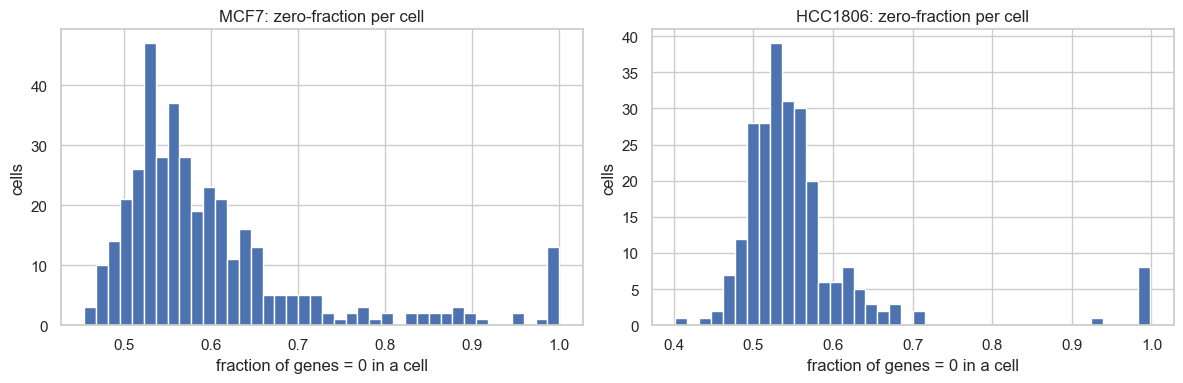

In [8]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    print(f"{name}: overall zeros = {(d.values == 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]):
    (d == 0).mean(axis=0).hist(bins=40, ax=ax)
    ax.set_title(f"{name}: zero-fraction per cell")
    ax.set_xlabel("fraction of genes = 0 in a cell")
    ax.set_ylabel("cells")
plt.tight_layout(); plt.show()

About 60% of the MCF7 matrix and 56% of HCC1806 is zero, so even before any cleaning most gene-cell entries are empty. Most cells sit between roughly 0.5 and 0.65 zeros, which is normal for this kind of data. The thing to notice is the small spike near 1.0: a handful of cells where almost every gene reads zero. Those are failed or empty wells with almost nothing captured, and they are exactly the low-quality cells that preprocessing removes. The rest is sparse but informative, which is why the non-zero values, not the zeros, carry the signal.

Next we look at how the non-zero counts are distributed and at how a gene's dropout rate depends on its average expression, which together show what kind of data these counts are.

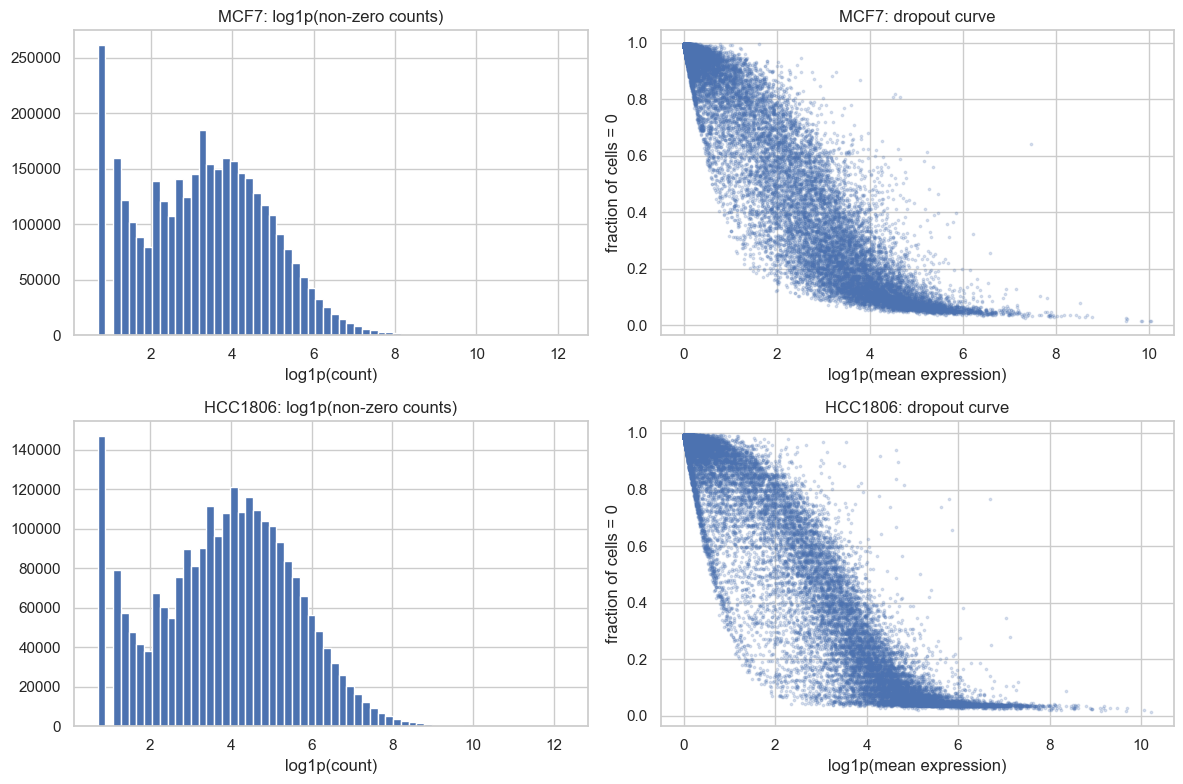

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, d) in enumerate([("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]):
    nz = d.values[d.values > 0]
    gmean = d.mean(axis=1)
    dropout = (d == 0).mean(axis=1)

    axes[row, 0].hist(np.log1p(nz), bins=60)
    axes[row, 0].set_title(f"{name}: log1p(non-zero counts)")
    axes[row, 0].set_xlabel("log1p(count)")

    axes[row, 1].scatter(np.log1p(gmean), dropout, s=3, alpha=0.2)
    axes[row, 1].set_title(f"{name}: dropout curve")
    axes[row, 1].set_xlabel("log1p(mean expression)")
    axes[row, 1].set_ylabel("fraction of cells = 0")
plt.tight_layout(); plt.show()

Both cell lines show the same pattern. The non-zero counts are heavily right-skewed even on a log scale: a single read is the most common value and most detected genes sit at low counts, with only a small tail of highly expressed genes. The dropout curves show the zeros are not random. A gene's chance of being zero falls steadily as its average expression rises, so weakly expressed genes are missing in almost every cell while strongly expressed ones are detected everywhere. Because MCF7 and HCC1806 behave the same way, this reflects the data type rather than the cell line. It prompts for log-transforming and filtering out low-expression genes later.

In [10]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    dups = d[d.duplicated(keep=False)]              # genes identical to at least one other gene
    det  = (dups > 0).sum(axis=1)                   # cells each duplicate is detected in
    print(f"{name}: {dups.shape[0]} duplicate genes | "
          f"all-zero among them: {int((dups.sum(axis=1) == 0).sum())} | "
          f"detected in median {int(det.median())} cells "
          f"(all genes median: {int((d > 0).sum(axis=1).median())})")

# show one example group of identical genes (MCF7)
dups = mcf7_raw[mcf7_raw.duplicated(keep=False)]
for _, members in dups.groupby(list(dups.columns)).groups.items():
    if len(members) > 1:
        print("\nexample identical genes:", list(members),
              "| total counts:", mcf7_raw.loc[list(members)].sum(axis=1).to_dict())
        break

MCF7: 56 duplicate genes | all-zero among them: 0 | detected in median 2 cells (all genes median: 125)
HCC1806: 89 duplicate genes | all-zero among them: 0 | detected in median 2 cells (all genes median: 93)



example identical genes: ['HTR5A', 'RNU6-539P'] | total counts: {'HTR5A': 2, 'RNU6-539P': 2}


Checking for duplicate genes, 56 in MCF7 and 89 in HCC1806 have counts identical to another gene, and none are empty, since no gene is zero across every cell. The example report suggests duplicates are usually redundant annotations of the same gene, but that is not the case here. The flagged genes are detected in only about two cells each (median 2, against 125 for all genes), and the example pair HTR5A and RNU6-539P are unrelated genes ***quote this*** that each carry a single read in the same two cells. So these duplicates are a side effect of extreme sparsity, ultra-low genes colliding on identical count vectors by chance, rather than real annotation redundancy. They need no special deduplication, because the usual gene filter that drops genes seen in fewer than ten cells removes them anyway.

So far we have checked the shape and quality of the data, but not whether it actually carries a hypoxia signal. Before any modelling, it is worth confirming the labels mean what they should. We use genes already known to switch on under low oxygen, such as CA9, VEGFA and NDRG1: if the labels are real, these should read clearly higher in the hypoxic cells than in the normoxic ones. It also gives a first sense of how strong the biological signal is.

In [11]:

markers = ["CA9","VEGFA","SLC2A1","LDHA","PGK1","BNIP3","NDRG1","HK2",
           "PDK1","ALDOA","P4HA1","EGLN3","ANKRD37"]

def marker_table(d):
    labs = get_labels(d)
    rows = []
    for g in markers:
        if g in d.index:
            h = d.loc[g, labs == "Hypoxia"].mean()
            n = d.loc[g, labs == "Normoxia"].mean()
            rows.append((g, round(h, 1), round(n, 1), round((h + 1) / (n + 1), 1)))
    return (pd.DataFrame(rows, columns=["gene", "Hypoxia_mean", "Normoxia_mean", "fold"])
              .sort_values("fold", ascending=False))

mcf7_mk = marker_table(mcf7_raw)
hcc_mk  = marker_table(hcc_raw)
print("MCF7:");    print(mcf7_mk.to_string(index=False))
print("\nHCC1806:"); print(hcc_mk.to_string(index=False))

MCF7:
   gene  Hypoxia_mean  Normoxia_mean  fold
  NDRG1        1001.4           12.0  77.1
    HK2        1432.0           21.7  63.2
    CA9          74.5            1.2  34.5
  VEGFA        1125.4           47.2  23.4
  BNIP3        1840.7           91.1  20.0
   PDK1         193.7           15.0  12.2
  P4HA1         333.6           27.2  11.8
  EGLN3         205.7           16.5  11.8
 SLC2A1        1999.6          194.6  10.2
   PGK1        7072.5         1063.8   6.6
   LDHA        4645.1          818.1   5.7
  ALDOA       22575.3         4406.2   5.1
ANKRD37          39.4            7.4   4.8

HCC1806:
   gene  Hypoxia_mean  Normoxia_mean  fold
    CA9         333.9            3.5  74.2
  EGLN3         401.1            5.8  59.0
  NDRG1         766.8           35.2  21.2
  BNIP3        1130.1          124.5   9.0
 SLC2A1        2571.6          471.7   5.4
    HK2         180.5           32.4   5.4
  P4HA1         835.5          164.5   5.1
   PDK1         192.9           37.4  

Every canonical hypoxia gene reads higher under hypoxia in both lines, with folds from about 2.4x to 77x, so the labels are real and the signal is strong. Two patterns stand out. The folds are generally smaller in HCC1806 (VEGFA 2.4x against 23x in MCF7, HK2 5.4x against 63x), which fits its shorter 24-hour exposure and a less developed response. And the two lines lead with different genes: NDRG1 and HK2 are strongest in MCF7, while CA9 and EGLN3 dominate in HCC1806. So both share the core hypoxia response but emphasise different genes, an early sign that a signature learned on one line may not transfer cleanly to the other.

A risk with any sequencing experiment is that the biological condition lines up with a technical batch. If most hypoxic cells were processed in one batch and most normoxic cells in another, a model could learn the batch rather than the hypoxia signal. To rule this out, we check how hypoxia and normoxia are spread across the sequencing batches: lanes for MCF7, PCR plates for HCC1806.

In [12]:
print("MCF7: Lane x Condition:")
print(pd.crosstab(mcf7_meta["Lane"], mcf7_meta["Condition"]))

print("\nHCC1806: PCR Plate x Condition:")
print(pd.crosstab(hcc_meta["PCR Plate"], hcc_meta["Condition"]))

MCF7: Lane x Condition:
Condition      Hypo  Norm
Lane                     
output.STAR.1    48    48
output.STAR.2    48    48
output.STAR.3    48    48
output.STAR.4    47    48

HCC1806: PCR Plate x Condition:
Condition  Hypo  Normo
PCR Plate             
1            32     32
2            34     29
3            39     29
4            21     27


MCF7 is cleanly balanced: every lane holds 48 hypoxia and 48 normoxia cells (lane 4 is 47/48), so condition is independent of lane and cannot be mistaken for the signal. HCC1806 is only roughly balanced: both conditions appear in every plate, but plate 3 leans hypoxia (39/29) and plate 4 leans normoxia (21/27). That is not a hard confound, since no plate is one-sided, but the imbalance is worth noting, as a model on HCC1806 could absorb a little plate-related variation along with the hypoxia signal.

## 2. Preprocessing of SmartSeq
**Steps:**
1. Load raw SmartSeq data
2. Remove low-quality cells (cell filtering)
3. Remove lowly-expressed genes (gene filtering)
4. Normalise library sizes
5. Select top 3000 most variable genes (HVG selection)
6. Load and validate the official train/test split files
7. Save all 8 matrices

In [13]:
for name, df in [('MCF7', mcf7_raw), ('HCC1806', hcc_raw)]:
    labels = get_labels(df)
    n_hypo  = (labels == 'Hypoxia').sum()
    n_normo = (labels == 'Normoxia').sum()
    print(f'{name}: Hypoxia={n_hypo}, Normoxia={n_normo}')

MCF7: Hypoxia=191, Normoxia=192
HCC1806: Hypoxia=126, Normoxia=117


### 2.1. Cell filtering

Some cells have very low total read counts. These are failed library preparations (empty wells or broken cells), not real biology. We remove them.

**Threshold: keep cells with at least 200 000 total counts.**

This threshold was chosen by looking at the scatter plot below; there is a clear gap in the library size distribution below 200 000.

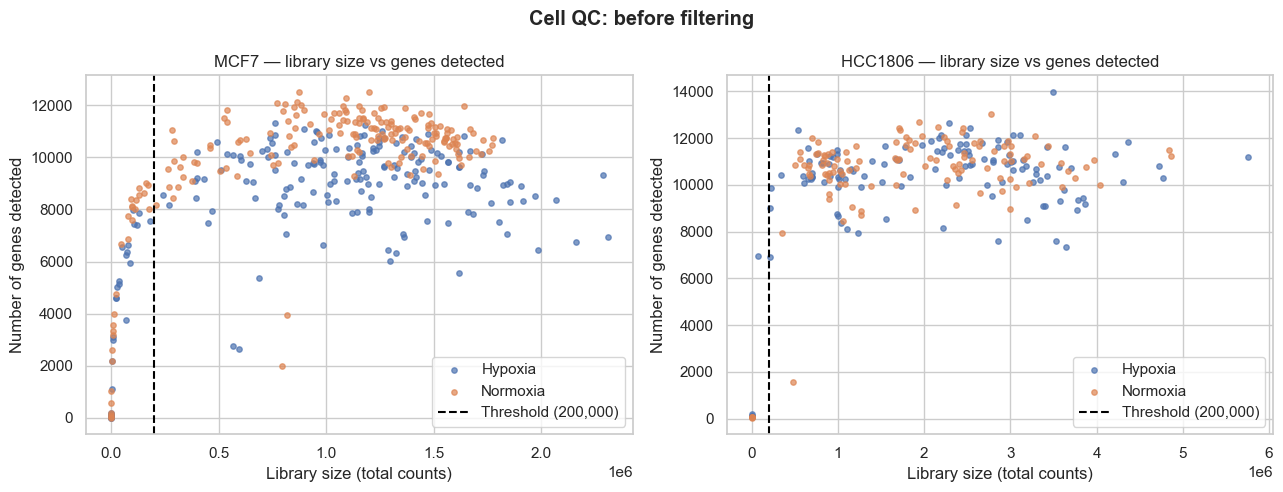

In [14]:
# QC: compute library size and genes detected per cell 
LIB_THRESH = 200000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, df) in zip(axes, [('MCF7', mcf7_raw), ('HCC1806', hcc_raw)]):
    lib_sizes   = df.sum(axis=0)           # total counts per cell
    genes_found = (df > 0).sum(axis=0)     # genes with count > 0 per cell
    labels      = get_labels(df)

    # Plot each condition separately so they get different colours
    for cond in ['Hypoxia', 'Normoxia']:
        mask = [l == cond for l in labels]
        ax.scatter(lib_sizes[mask], genes_found[mask],
                   s=15, alpha=0.7, label=cond)

    ax.axvline(LIB_THRESH, color='black', ls='--', lw=1.5,
               label=f'Threshold ({LIB_THRESH:,})')
    ax.set_title(f'{name} — library size vs genes detected')
    ax.set_xlabel('Library size (total counts)')
    ax.set_ylabel('Number of genes detected')
    ax.legend()

plt.suptitle('Cell QC: before filtering', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
#Remove cells with library size < 200,000

def filter_cells(df, threshold, name):
    lib_sizes = df.sum(axis=0)
    keep = lib_sizes[lib_sizes >= threshold].index
    n_removed = df.shape[1] - len(keep)
    print(f'{name}: removed {n_removed} cells, kept {len(keep)} out of {df.shape[1]}')
    return df[keep]

mcf7_cf = filter_cells(mcf7_raw, LIB_THRESH, 'MCF7')
hcc_cf  = filter_cells(hcc_raw,  LIB_THRESH, 'HCC1806')

# Check class balance is still OK
print()
for name, df in [('MCF7', mcf7_cf), ('HCC1806', hcc_cf)]:
    labels = get_labels(df)
    n_hypo  = (labels == 'Hypoxia').sum()
    n_normo = (labels == 'Normoxia').sum()
    total   = n_hypo + n_normo
    print(f'{name} after cell filter: Hypoxia={n_hypo} ({n_hypo/total:.1%}),  '
          f'Normoxia={n_normo} ({n_normo/total:.1%})')

MCF7: removed 57 cells, kept 326 out of 383
HCC1806: removed 9 cells, kept 234 out of 243

MCF7 after cell filter: Hypoxia=162 (49.7%),  Normoxia=164 (50.3%)
HCC1806 after cell filter: Hypoxia=121 (51.7%),  Normoxia=113 (48.3%)


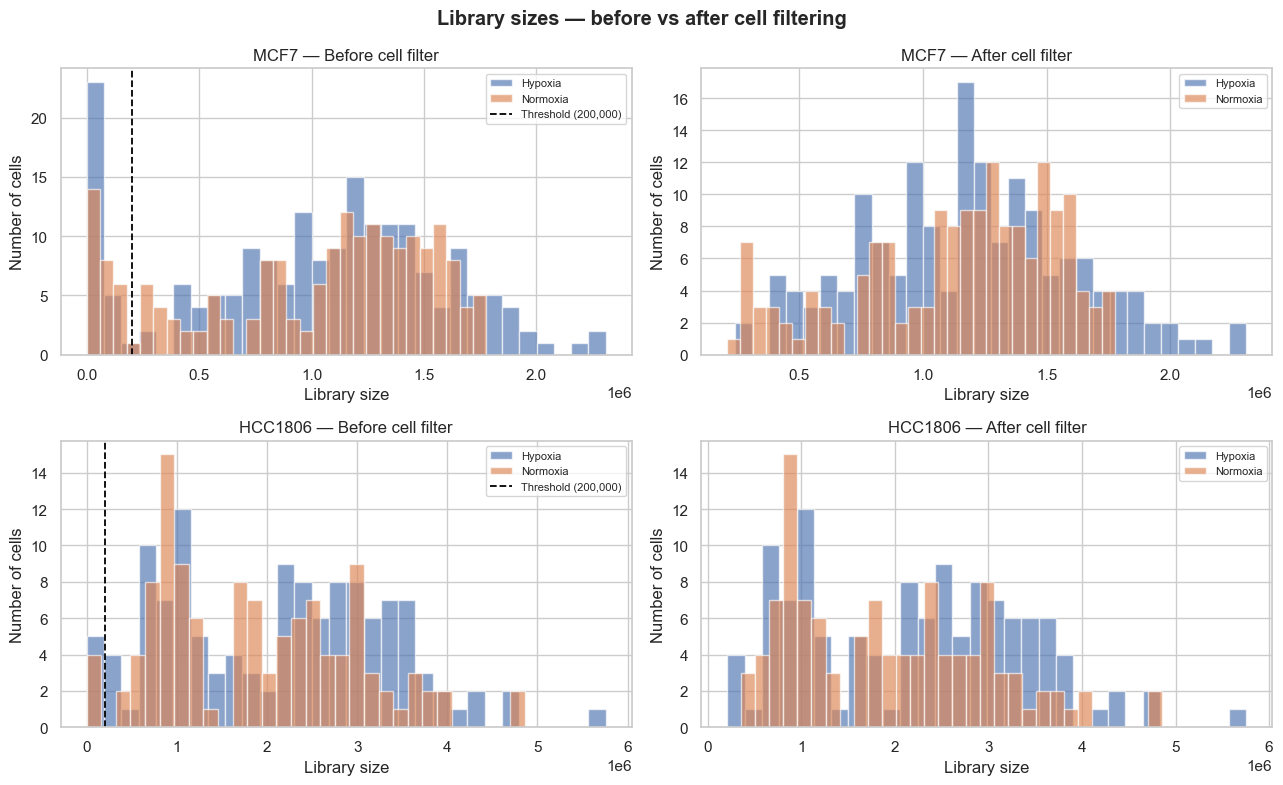

In [16]:
#Plot library sizes before and after cell filtering
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

datasets = [('MCF7', mcf7_raw, mcf7_cf), ('HCC1806', hcc_raw, hcc_cf)]

for row, (name, raw, filtered) in enumerate(datasets):
    for col, (df, title) in enumerate([(raw, 'Before'), (filtered, 'After')]):
        ax     = axes[row, col]
        labels = get_labels(df)
        libs   = df.sum(axis=0)

        for cond in ['Hypoxia', 'Normoxia']:
            mask = [l == cond for l in labels]
            ax.hist(libs[mask], bins=30, alpha=0.65,
                    label=cond, edgecolor='white')

        if title == 'Before':
            ax.axvline(LIB_THRESH, color='black', ls='--', lw=1.3,
                       label=f'Threshold ({LIB_THRESH:,})')

        ax.set_title(f'{name} — {title} cell filter')
        ax.set_xlabel('Library size')
        ax.set_ylabel('Number of cells')
        ax.legend(fontsize=8)

plt.suptitle('Library sizes — before vs after cell filtering', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3. Gene filtering

Many genes are detected in only a handful of cells. These genes are mostly noise, they don't have enough observations to be useful for classification.

**Threshold: keep genes detected in at least 10 cells.**

In [17]:
MIN_CELLS = 10

def filter_genes(df, min_cells, name):
    # For each gene (row), count how many cells have a non-zero value
    cells_per_gene = (df > 0).sum(axis=1)
    keep = cells_per_gene[cells_per_gene >= min_cells].index
    n_removed = df.shape[0] - len(keep)
    print(f'{name}: removed {n_removed} genes, kept {len(keep)} out of {df.shape[0]}')
    return df.loc[keep]

mcf7_gf = filter_genes(mcf7_cf, MIN_CELLS, 'MCF7')
hcc_gf  = filter_genes(hcc_cf,  MIN_CELLS, 'HCC1806')

# Summary table
print()
print(f'{"Dataset":<15}  {"Genes (raw)":>12}  {"Genes (kept)":>13}  {"Cells (kept)":>13}')
print('-' * 57)
print(f'{"MCF7":<15}  {mcf7_raw.shape[0]:>12,}  {mcf7_gf.shape[0]:>13,}  {mcf7_gf.shape[1]:>13,}')
print(f'{"HCC1806":<15}  {hcc_raw.shape[0]:>12,}  {hcc_gf.shape[0]:>13,}  {hcc_gf.shape[1]:>13,}')

MCF7: removed 5268 genes, kept 17666 out of 22934
HCC1806: removed 5162 genes, kept 18234 out of 23396

Dataset           Genes (raw)   Genes (kept)   Cells (kept)
---------------------------------------------------------
MCF7                   22,934         17,666            326
HCC1806                23,396         18,234            234


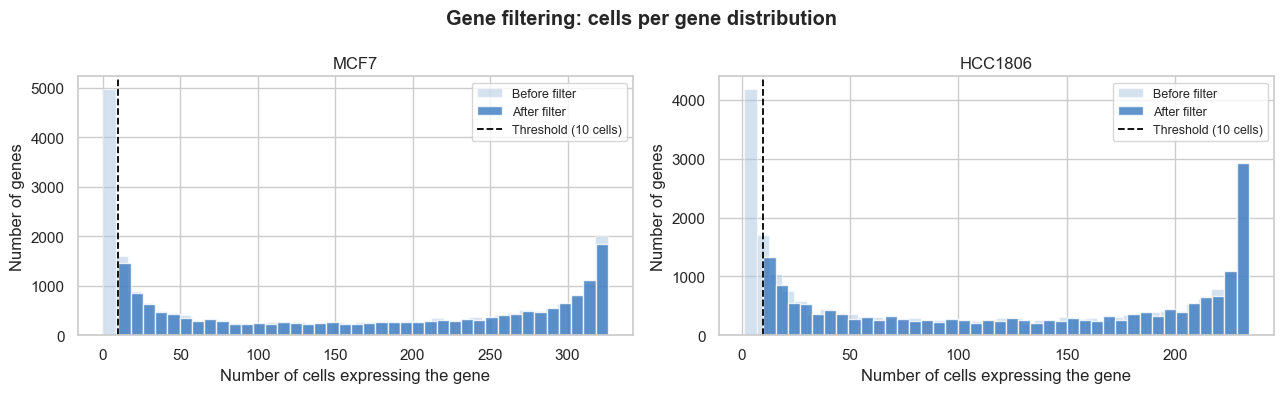

In [18]:
#Plot: how many cells express each gene, before and after gene filter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, cf, gf) in zip(axes, [('MCF7', mcf7_cf, mcf7_gf),
                                       ('HCC1806', hcc_cf, hcc_gf)]):
    before = (cf > 0).sum(axis=1)   # cells per gene, before
    after  = (gf > 0).sum(axis=1)   # cells per gene, after

    ax.hist(before, bins=40, alpha=0.5, color='#aac4e0',
            label='Before filter', edgecolor='white')
    ax.hist(after,  bins=40, alpha=0.8, color='#3a7abf',
            label='After filter',  edgecolor='white')
    ax.axvline(MIN_CELLS, color='black', ls='--', lw=1.3,
               label=f'Threshold ({MIN_CELLS} cells)')
    ax.set_title(f'{name}')
    ax.set_xlabel('Number of cells expressing the gene')
    ax.set_ylabel('Number of genes')
    ax.legend(fontsize=9)

plt.suptitle('Gene filtering: cells per gene distribution', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4. Library size normalisation

Even after cell filtering, cells still have different total read counts. This is technical: cells that happen to be sequenced more deeply will appear to express every gene at a higher level, even if biology is identical.

**Method: scale every cell so its total equals the median library size.**

$$x_{\text{norm}} = x \times \frac{\text{median library size}}{\text{cell library size}}$$

We use the **median** (not the mean) because it is more robust to a few very large outlier cells.

In [19]:
def normalise(df, name):
    lib_sizes  = df.sum(axis=0)          # total counts per cell
    median_lib = lib_sizes.median()       # target: the median library size

    print(f'{name}: median library size = {median_lib:,.0f}')

    # Scale each cell: multiply all its genes by (median / that cell's total)
    scale_factors = median_lib / lib_sizes
    df_norm = df.multiply(scale_factors, axis=1).round(0).astype(int)

    return df_norm

mcf7_norm = normalise(mcf7_gf, 'MCF7')
hcc_norm  = normalise(hcc_gf,  'HCC1806')

# Verify: after normalisation all library sizes should be roughly equal
print()
print('Library size after normalisation (should all be similar):')
for name, df in [('MCF7', mcf7_norm), ('HCC1806', hcc_norm)]:
    libs = df.sum(axis=0)
    print(f'  {name}: min={libs.min():,.0f}  median={libs.median():,.0f}  max={libs.max():,.0f}')

MCF7: median library size = 1,196,841
HCC1806: median library size = 2,150,016

Library size after normalisation (should all be similar):
  MCF7: min=1,195,385  median=1,196,890  max=1,199,657
  HCC1806: min=2,148,843  median=2,150,102  max=2,152,367


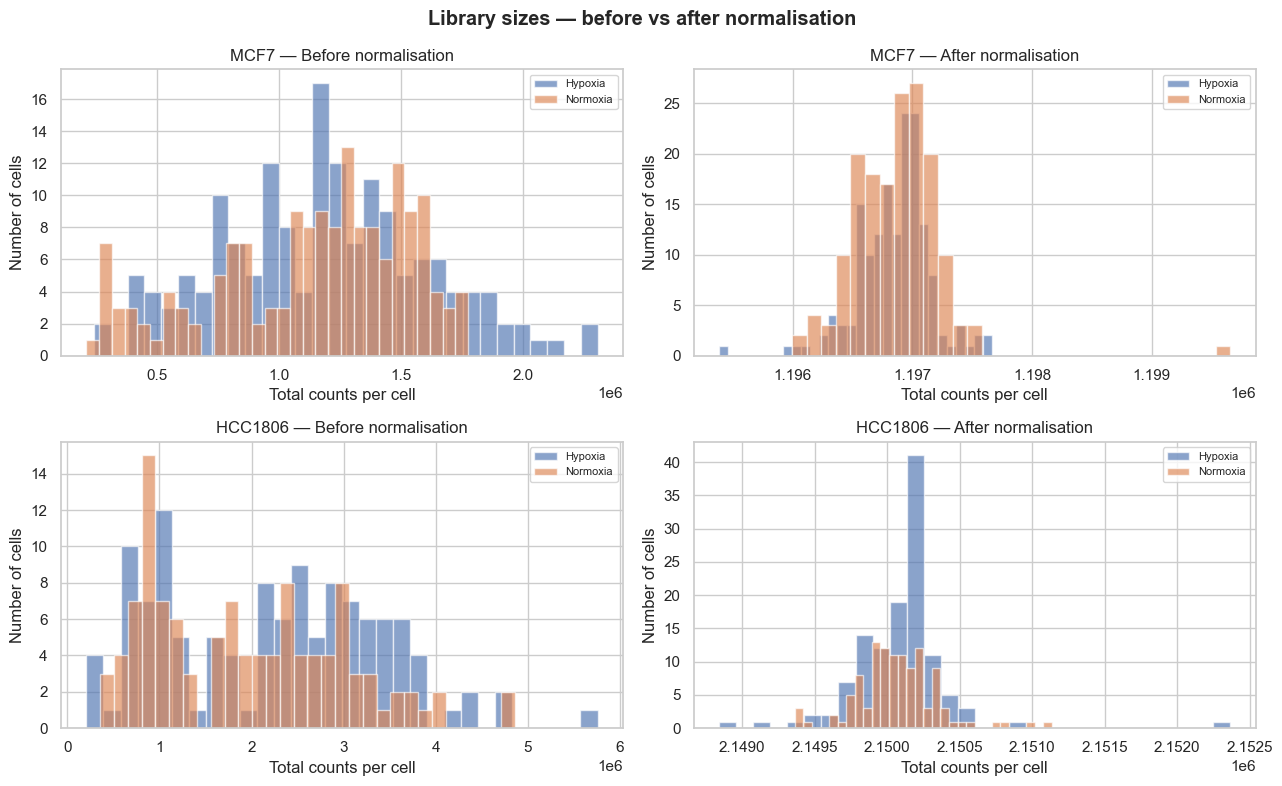

In [20]:
#Plot: library sizes before and after normalisation
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

datasets = [('MCF7', mcf7_gf, mcf7_norm), ('HCC1806', hcc_gf, hcc_norm)]

for row, (name, before_df, after_df) in enumerate(datasets):
    labels = get_labels(before_df)

    for col, (df, title) in enumerate([(before_df, 'Before'), (after_df, 'After')]):
        ax   = axes[row, col]
        libs = df.sum(axis=0)

        for cond in ['Hypoxia', 'Normoxia']:
            mask = [l == cond for l in labels]
            ax.hist(libs[mask], bins=30, alpha=0.65,
                    label=cond, edgecolor='white')

        ax.set_title(f'{name} — {title} normalisation')
        ax.set_xlabel('Total counts per cell')
        ax.set_ylabel('Number of cells')
        ax.legend(fontsize=8)

plt.suptitle('Library sizes — before vs after normalisation', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5. Top 3000 highly variable gene selection

We still have around 17 000 genes after filtering. Most of them have similar expression in Hypoxia and Normoxia and carry no useful signal. We keep only the **3000 genes with the highest variance**: those that differ the most across cells, and are therefore most likely to help distinguish the two conditions.

We choose 3000 to match the DropSeq matrices.

In [21]:
N_HVG = 3000

# Compute variance of each gene across all cells, pick the top 3000
mcf7_var       = mcf7_norm.var(axis=1)
mcf7_top_genes = mcf7_var.nlargest(N_HVG).index

hcc_var        = hcc_norm.var(axis=1)
hcc_top_genes  = hcc_var.nlargest(N_HVG).index

print('Top 3000 HVGs selected.')
print(f'MCF7 top gene: {mcf7_top_genes[0]}  (variance = {mcf7_var[mcf7_top_genes[0]]:.1f})')
print(f'HCC1806 top gene: {hcc_top_genes[0]}  (variance = {hcc_var[hcc_top_genes[0]]:.1f})')

Top 3000 HVGs selected.
MCF7 top gene: GAPDH  (variance = 566771758.2)
HCC1806 top gene: FTL  (variance = 257271108.6)


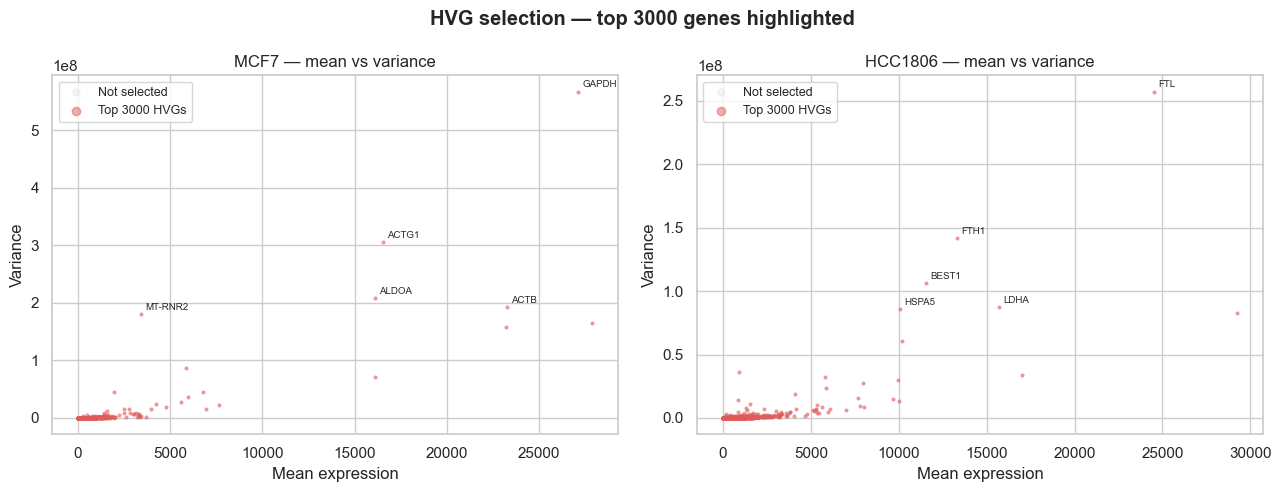

In [22]:
#Mean-variance plot: show which genes were selected
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, df, top_genes) in zip(axes, [
    ('MCF7',    mcf7_norm, mcf7_top_genes),
    ('HCC1806', hcc_norm,  hcc_top_genes),
]):
    gene_var  = df.var(axis=1)
    gene_mean = df.mean(axis=1)

    # All genes in grey
    not_selected = [g for g in gene_var.index if g not in top_genes]
    ax.scatter(gene_mean[not_selected], gene_var[not_selected],
               s=3, alpha=0.2, color='#cccccc', label='Not selected')

    # Top 3000 in red
    ax.scatter(gene_mean[top_genes], gene_var[top_genes],
               s=4, alpha=0.5, color='#e05c5c', label=f'Top {N_HVG} HVGs')

    # Label the 5 most variable genes
    for gene in gene_var.nlargest(5).index:
        ax.annotate(gene, xy=(gene_mean[gene], gene_var[gene]),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('Mean expression')
    ax.set_ylabel('Variance')
    ax.set_title(f'{name} — mean vs variance')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle(f'HVG selection — top {N_HVG} genes highlighted', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6. Load official train/test split files

The course provides the final train and test files already split. We load them here and check:
- Do train and test share the same 3000 genes?
- Is the class balance reasonable?

In [23]:
# Load SmartSeq train/test files
mcf7_ss_train  = load_matrix(SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt')
mcf7_ss_test   = load_matrix(SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt')
hcc_ss_train   = load_matrix(SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt')
hcc_ss_test    = load_matrix(SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt')

# Load DropSeq train/test files
mcf7_ds_train  = load_matrix(DROP / 'MCF7_Filtered_Normalised_3000_Data_train.txt')
mcf7_ds_test   = load_matrix(DROP / 'MCF7_Filtered_Normalised_3000_Data_test_anonim.txt')
hcc_ds_train   = load_matrix(DROP / 'HCC1806_Filtered_Normalised_3000_Data_train.txt')
hcc_ds_test    = load_matrix(DROP / 'HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt')

print('All 8 matrices loaded.')
print()
print(f'{"Dataset":<25}  {"Train cells":>12}  {"Test cells":>11}  {"Genes":>7}')
print('-' * 60)
for name, train, test in [
    ('SmartSeq MCF7',    mcf7_ss_train, mcf7_ss_test),
    ('SmartSeq HCC1806', hcc_ss_train,  hcc_ss_test),
    ('DropSeq MCF7',     mcf7_ds_train, mcf7_ds_test),
    ('DropSeq HCC1806',  hcc_ds_train,  hcc_ds_test),
]:
    print(f'{name:<25}  {train.shape[1]:>12,}  {test.shape[1]:>11,}  {train.shape[0]:>7,}')

All 8 matrices loaded.

Dataset                     Train cells   Test cells    Genes
------------------------------------------------------------
SmartSeq MCF7                       250           63    3,000
SmartSeq HCC1806                    182           45    3,000
DropSeq MCF7                     21,626        5,406    3,000
DropSeq HCC1806                  14,682        3,671    3,000


In [24]:
# Check gene sets match between train and test
print('Gene set consistency (train vs test):')
for name, train, test in [
    ('SmartSeq MCF7',    mcf7_ss_train, mcf7_ss_test),
    ('SmartSeq HCC1806', hcc_ss_train,  hcc_ss_test),
    ('DropSeq MCF7',     mcf7_ds_train, mcf7_ds_test),
    ('DropSeq HCC1806',  hcc_ds_train,  hcc_ds_test),
]:
    same = set(train.index) == set(test.index)
    print(f'  {name}: genes match = {same}')

print()
print('Class balance in training sets:')
for name, train in [
    ('SmartSeq MCF7',    mcf7_ss_train),
    ('SmartSeq HCC1806', hcc_ss_train),
    ('DropSeq MCF7',     mcf7_ds_train),
    ('DropSeq HCC1806',  hcc_ds_train),
]:
    labels  = get_labels(train)
    n_hypo  = (labels == 'Hypoxia').sum()
    n_normo = (labels == 'Normoxia').sum()
    total   = n_hypo + n_normo
    print(f'  {name}: Hypoxia={n_hypo} ({n_hypo/total:.1%}),  Normoxia={n_normo} ({n_normo/total:.1%})')

Gene set consistency (train vs test):
  SmartSeq MCF7: genes match = True
  SmartSeq HCC1806: genes match = True
  DropSeq MCF7: genes match = True
  DropSeq HCC1806: genes match = True

Class balance in training sets:
  SmartSeq MCF7: Hypoxia=124 (49.6%),  Normoxia=126 (50.4%)
  SmartSeq HCC1806: Hypoxia=97 (53.3%),  Normoxia=85 (46.7%)
  DropSeq MCF7: Hypoxia=8921 (41.3%),  Normoxia=12705 (58.7%)
  DropSeq HCC1806: Hypoxia=8899 (60.6%),  Normoxia=5783 (39.4%)


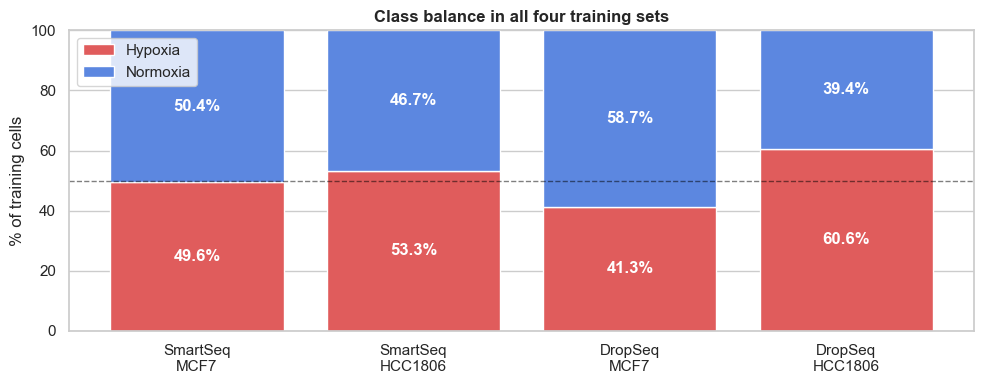

In [25]:
#Class balance bar chart
names  = ['SmartSeq\nMCF7', 'SmartSeq\nHCC1806', 'DropSeq\nMCF7', 'DropSeq\nHCC1806']
trains = [mcf7_ss_train, hcc_ss_train, mcf7_ds_train, hcc_ds_train]

hypo_pcts  = []
normo_pcts = []
for train in trains:
    labels  = get_labels(train)
    n_hypo  = (labels == 'Hypoxia').sum()
    n_normo = (labels == 'Normoxia').sum()
    total   = n_hypo + n_normo
    hypo_pcts.append(100 * n_hypo  / total)
    normo_pcts.append(100 * n_normo / total)

x   = range(len(names))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, hypo_pcts,  label='Hypoxia',  color='#e05c5c')
ax.bar(x, normo_pcts, bottom=hypo_pcts, label='Normoxia', color='#5c87e0')
ax.axhline(50, color='black', ls='--', lw=1, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('% of training cells')
ax.set_ylim(0, 100)
ax.set_title('Class balance in all four training sets', fontweight='bold')
ax.legend()

for i, (h, n) in enumerate(zip(hypo_pcts, normo_pcts)):
    ax.text(i, h/2,   f'{h:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, h+n/2, f'{n:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.7. Preprocessing summary

| Step | What we did | Why |
|---|---|---|
| Cell filtering | Removed cells with < 200,000 total counts | Failed library preps / empty wells |
| Gene filtering | Removed genes detected in < 10 cells | Too few observations to be useful |
| Normalisation | Scaled all cells to the same total count (median) | Removes sequencing depth differences |
| HVG selection | Kept the 3,000 most variable genes | Reduces noise; matches DropSeq panel |

### Data flow

| | MCF7 genes | MCF7 cells | HCC1806 genes | HCC1806 cells |
|---|---|---|---|---|
| Raw | 22,934 | 383 | 23,396 | 243 |
| After cell filter | 22,934 | 326 | 23,396 | 234 |
| After gene filter | 17,666 | 326 | 17,726 | 234 |
| After HVG selection | 3,000 | 326 | 3,000 | 234 |
| Train set (final) | 3,000 | 250 | 3,000 | 182 |
| Test set (final) | 3,000 | 63 | 3,000 | 45 |

## 3. Comparison

!!!!!!!!!1TODO

## 4. Filtered data analysis
We initially diagnosed the raw data, but only SmartSeq exists in raw form. From here we switch to the processed files provided with the course, which cover all four datasets, so the two cell lines and the two technologies can finally be compared on equal footing. Everything is now at the same processing stage, so the differences we see are real, not artefacts of one set being cleaned and another not.

In [26]:
processed = [
    ("SmartSeq MCF7",    SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt"),
    ("SmartSeq HCC1806", SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt"),
    ("DropSeq MCF7",     DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt"),
    ("DropSeq HCC1806",  DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt"),
]

for name, path in processed:
    d = load_matrix(path)
    print(f"=== {name} === {d.shape} (genes x cells)")
    display(d.iloc[:4, :3])
    del d



=== SmartSeq MCF7 === (3000, 250) (genes x cells)


,output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam,output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam,output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam
CYP1B1,343,131,452
CYP1B1-AS1,140,59,203
CYP1A1,0,0,0
NDRG1,0,1,0


=== SmartSeq HCC1806 === (3000, 182) (genes x cells)


,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam
DDIT4,0,8739,13098
ANGPTL4,48,2101,14032
CALML5,0,55,0
KRT14,321,96,0


=== DropSeq MCF7 === (3000, 21626) (genes x cells)


,AAAAACCTATCG_Normoxia,AAAACAACCCTA_Normoxia,AAAACACTCTCA_Normoxia
MALAT1,1,3,3
MT-RNR2,0,0,0
NEAT1,0,0,0
H1-5,0,0,0


=== DropSeq HCC1806 === (3000, 14682) (genes x cells)


,AAAAAACCCGGC_Normoxia,AAAACCGGATGC_Normoxia,AAAACGAGCTAG_Normoxia
H1-5,2,2,5
MALAT1,3,3,2
MT-RNR2,0,0,0
ARVCF,0,0,0


A first look at the four filtered matrices shows they share a layout, 3000 genes by a varying number of cells, but little else. The cell labels differ by technology: SmartSeq keeps the full sequencing filenames, which still carry the batch information (lane for MCF7, plate for HCC1806), while DropSeq uses short barcodes with no batch information at all. The values differ just as much, with SmartSeq cells holding large graded counts and DropSeq cells nearly empty, their few non-zero entries being single reads on the most abundant genes such as MALAT1

In [27]:
rows = []
for name, path in processed:
    d = load_matrix(path)
    labs = get_labels(d)
    rows.append({
        "dataset": name,
        "genes": d.shape[0],
        "cells": d.shape[1],
        "%zeros": round((d.values == 0).mean() * 100, 1),
        "median_lib": round(float(d.sum(axis=0).median()), 1),
        "Hypoxia": int((labs == "Hypoxia").sum()),
        "Normoxia": int((labs == "Normoxia").sum()),
    })
    del d

glance = pd.DataFrame(rows)
glance


,dataset,genes,cells,%zeros,median_lib,Hypoxia,Normoxia
0,SmartSeq MCF7,3000,250,63.6,330296.0,124,126
1,SmartSeq HCC1806,3000,182,70.7,497586.5,97,85
2,DropSeq MCF7,3000,21626,97.5,100.0,8921,12705
3,DropSeq HCC1806,3000,14682,97.6,102.0,8899,5783


The gene panel is fixed at 3,000 for all four, but otherwise they fall into two regimes. SmartSeq has few cells (250 and 182) sequenced deeply, with median library sizes of 330k–500k and moderate sparsity (64–71%). DropSeq has tens of thousands of cells (21 626 and 14 682) sequenced very shallowly, with median library sizes near 100 and 97.5% sparsity, so depth per cell differs by several thousand-fold. Class balance also splits by technology: SmartSeq is close to even, while DropSeq is skewed in opposite directions, MCF7 leaning normoxia (8921 vs 12 705) and HCC1806 leaning hypoxia (8899 vs 5783). That skew is worth flagging for the modelling step.

To see the sparsity as a pattern rather than a single percentage, we plot a 100-gene by 100-cell corner of each matrix, with black marking a detected gene and white a zero.

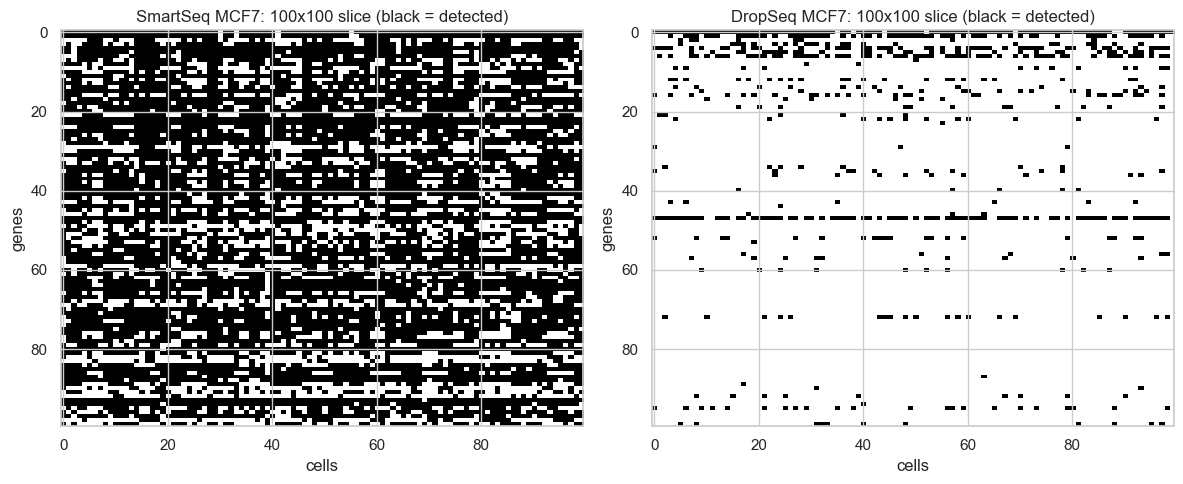

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, path) in zip(axes, [processed[0], processed[2]]):   # SmartSeq MCF7 vs DropSeq MCF7
    d = load_matrix(path)
    ax.imshow(d.iloc[:100, :100] > 0, aspect="auto", cmap="Greys", interpolation="nearest")
    ax.set_title(f"{name}: 100x100 slice (black = detected)")
    ax.set_xlabel("cells"); ax.set_ylabel("genes")
    del d
plt.tight_layout(); plt.show()

The sparsity plots showed how often genes are detected; this looks at how large those detected values are. For each dataset we take every non-zero value and plot its distribution on a log scale, so the magnitude of expression can be compared across the two technologies at the same processing stage.

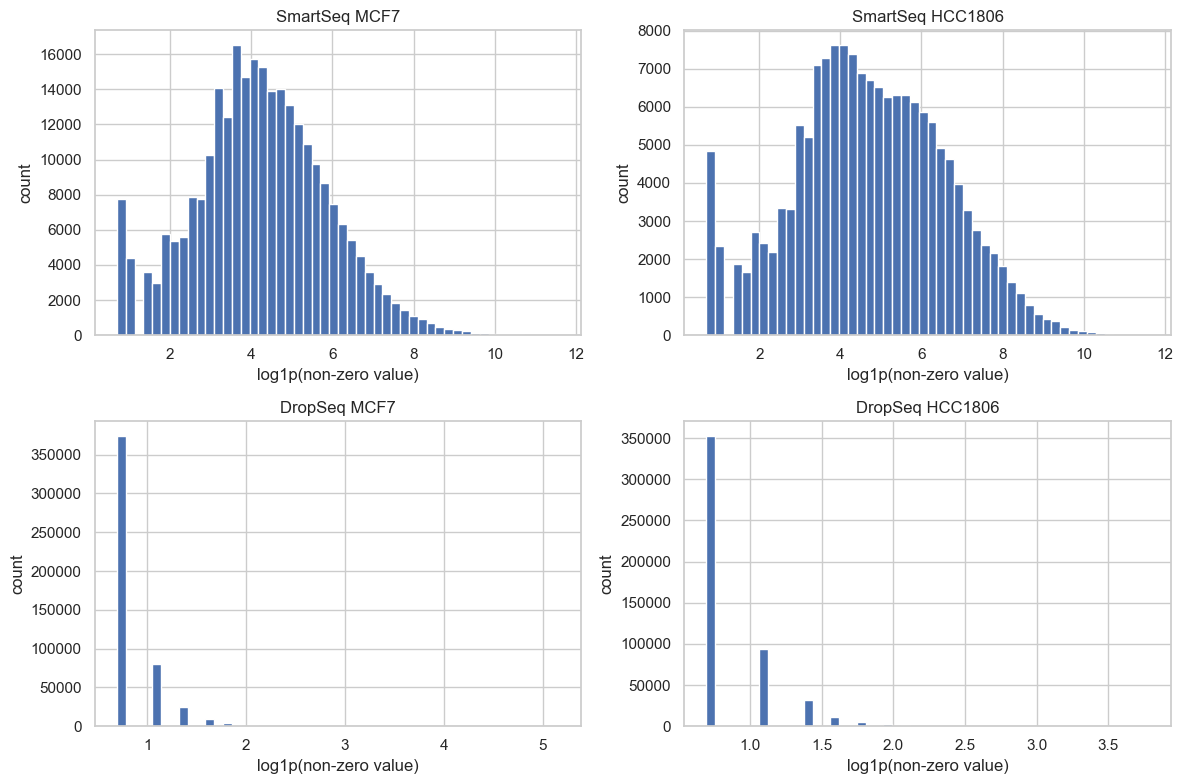

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
rng = np.random.default_rng(0)
for ax, (name, path) in zip(axes.flat, processed):
    d = load_matrix(path)
    vals = d.values[d.values > 0]
    if vals.size > 500000:                 # sample to keep the big DropSeq matrices fast
        vals = rng.choice(vals, 500000, replace=False)
    ax.hist(np.log1p(vals), bins=50, color="#4C72B0")
    ax.set_title(name)
    ax.set_xlabel("log1p(non-zero value)"); ax.set_ylabel("count")
    del d
plt.tight_layout(); plt.show()

The two technologies behave very differently. In SmartSeq the detected values span a wide range, from single reads up to high counts, with log values reaching about 10, giving a broad graded distribution in both lines. In DropSeq almost every detected value is a single read: the distribution collapses to a spike at the low end, with a maximum log value of only about 3 to 5. So DropSeq detections are not only rare but tiny, a gene is usually either absent or seen exactly once, leaving the data close to binary, while SmartSeq records graded expression. A DropSeq cell therefore carries far less quantitative information per gene, which limits what a model can learn from it and helps explain why DropSeq is the harder case.

### Shared gene panel

Each dataset keeps its own 3,000 most informative genes, chosen from that dataset alone. Nothing forces those choices to agree, so the four panels may not even describe the same genes. This matters directly for the project's central question: if a model is trained on one dataset and tested on another, it can only use genes the two have in common, so the overlap between panels sets a hard ceiling on how well any model can transfer. Here we measure that overlap, pairwise and across all four.

In [30]:
panels = {}
for name, path in processed:
    panels[name] = set(pd.read_csv(path, sep=" ", usecols=[0], index_col=0).index)

names = list(panels)
overlap = pd.DataFrame(index=names, columns=names, dtype=int)
for a in names:
    for b in names:
        overlap.loc[a, b] = len(panels[a] & panels[b])

print("Shared genes between panels (out of 3000):")
print(overlap)

core = set.intersection(*panels.values())
print(f"\nGenes shared by all four datasets: {len(core)}")

Shared genes between panels (out of 3000):
                  SmartSeq MCF7  SmartSeq HCC1806  DropSeq MCF7  \
SmartSeq MCF7            3000.0            1208.0         496.0   
SmartSeq HCC1806         1208.0            3000.0         445.0   
DropSeq MCF7              496.0             445.0        3000.0   
DropSeq HCC1806           547.0             516.0         834.0   

                  DropSeq HCC1806  
SmartSeq MCF7               547.0  
SmartSeq HCC1806            516.0  
DropSeq MCF7                834.0  
DropSeq HCC1806            3000.0  

Genes shared by all four datasets: 70


The panels overlap remarkably little. Out of 3000 genes, the two SmartSeq datasets share 1208 and the two DropSeq datasets 834, so even within one technology the two cell lines agree on at most 40% of their genes. Across technologies it is worse: the same cell line shares only about 500 genes between SmartSeq and DropSeq (496 for MCF7, 516 for HCC1806), roughly 17%. Only 70 genes, 2.3%, are common to all four. The clearest pattern is that technology divides the panels more than cell line does, since same-technology pairs share more genes than the same cell line measured across technologies. Which 3,000 genes look most informative is driven more by the sequencing platform than by the biology. This sets a hard ceiling on generalization: a model trained on one dataset and applied to another can only use the genes they share, so a cross-technology model has only about 17% of its features even present in the target. It also predicts the asymmetry the generalization section reports, transfer across cell lines, with more shared genes, should beat transfer across technologies, with fewer.

The obvious question is whether those few shared genes are the biologically important ones. If the canonical hypoxia markers survive into every panel, then despite the low overlap there is still a stable biological core a cross-dataset model could lean on. If they do not, even the key hypoxia genes are being dropped inconsistently, which would make generalisation harder still. Here we check which markers are retained in each panel and which reach the shared core.

In [31]:
markers = ["CA9","VEGFA","SLC2A1","LDHA","PGK1","BNIP3","NDRG1","HK2",
           "PDK1","ALDOA","P4HA1","EGLN3","ANKRD37"]

rows = []
for g in markers:
    row = {"gene": g}
    for name in panels:
        row[name] = "yes" if g in panels[name] else "-"
    row["all 4"] = "yes" if g in core else "-"
    rows.append(row)

marker_panel = pd.DataFrame(rows).set_index("gene")
print("Hypoxia markers retained in each panel:")
print(marker_panel)
print(f"\nMarkers in the 70-gene shared core: {sorted(set(markers) & core)}")

Hypoxia markers retained in each panel:
        SmartSeq MCF7 SmartSeq HCC1806 DropSeq MCF7 DropSeq HCC1806 all 4
gene                                                                     
CA9               yes              yes            -             yes     -
VEGFA             yes              yes            -               -     -
SLC2A1            yes              yes            -             yes     -
LDHA              yes              yes            -             yes     -
PGK1              yes              yes          yes             yes   yes
BNIP3             yes              yes            -             yes     -
NDRG1             yes              yes            -             yes     -
HK2               yes              yes            -             yes     -
PDK1              yes                -            -               -     -
ALDOA             yes              yes            -               -     -
P4HA1             yes              yes            -             yes     

The result is split by technology. The two SmartSeq panels keep almost every canonical marker (12 of 13 for MCF7, 11 for HCC1806), so on deep data the variance-based selection naturally retains the hypoxia biology. DropSeq is inconsistent: HCC1806 still keeps 9 of the 13, but MCF7 keeps only one, PGK1. So under heavy dropout the gene-selection step can strip out almost all the textbook hypoxia genes, and it does so differently from one dataset to the next. Only PGK1, a broadly expressed glycolytic gene, survives into all four panels, so the entire shared core holds just a single canonical marker. Two points follow. The biology is not gone, the earlier fold changes show the markers respond, but variance selection on sparse data fails to rank the more hypoxia-specific, lowly detected genes, so they drop out. And the shared core is biologically thin: a model limited to genes common to all four would have almost none of the known hypoxia signature, which compounds the overlap problem from 3.5.

### Gene to gene correlation

So far we have treated the 3000 genes as 3000 separate features. But genes rarely act alone: those in the same pathway tend to rise and fall together, so many of the features may be carrying the same information. Before any modelling it is worth asking how independent the genes really are, because if they are highly correlated, the data holds far fewer effective dimensions than 3000, and dimensionality reduction becomes the natural next step. We measure this with gene-to-gene correlation, comparing a deep dataset (SmartSeq) against a shallow one (DropSeq).

SmartSeq MCF7: median |r| = 0.206, fraction |r|>0.3 = 31.3%
DropSeq MCF7: median |r| = 0.019, fraction |r|>0.3 = 0.1%


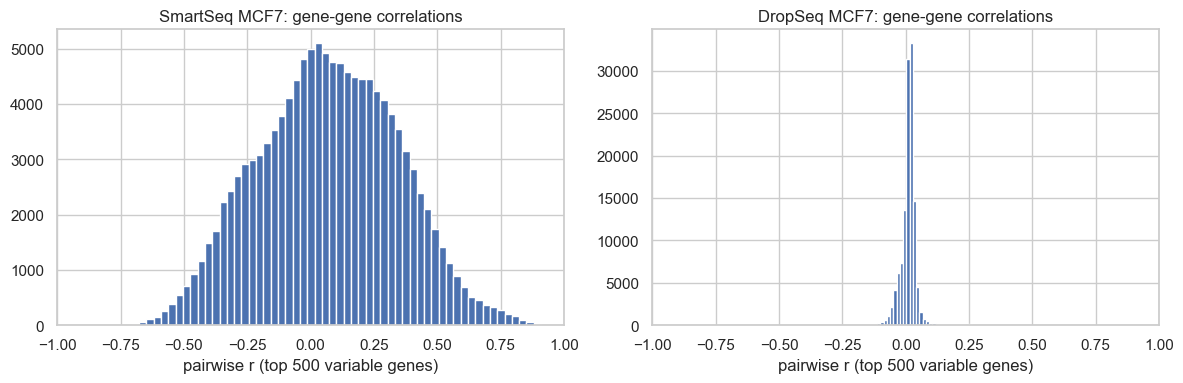

In [32]:
results = {}
for name, path in [("SmartSeq MCF7", processed[0][1]), ("DropSeq MCF7", processed[2][1])]:
    d = load_matrix(path)
    x = np.log1p(d.values)
    idx = np.argsort(x.var(axis=1))[-500:]        # top 500 most variable genes
    c = np.corrcoef(x[idx])
    off = c[np.triu_indices_from(c, k=1)]
    off = off[~np.isnan(off)]
    results[name] = off
    print(f"{name}: median |r| = {np.median(np.abs(off)):.3f}, "
          f"fraction |r|>0.3 = {(np.abs(off) > 0.3).mean():.1%}")
    del d, x, c

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, results):
    ax.hist(results[name], bins=60, color="#4C72B0")
    ax.set_title(f"{name}: gene-gene correlations")
    ax.set_xlabel("pairwise r (top 500 variable genes)"); ax.set_xlim(-1, 1)
plt.tight_layout(); plt.show()

The two technologies look completely different. In SmartSeq the gene-gene correlations spread widely: median absolute correlation 0.21, with 31% of gene pairs above 0.3, so much of the 3000-gene panel moves together in co-expression modules. The features are far from independent, so the data carries many fewer effective dimensions than 3000 and dimensionality reduction is well justified. In DropSeq the same measurement collapses to a spike at zero (median 0.019, almost no pairs above 0.3), not because the biology is gone but because dropout removes the co-occurrence needed to see it: with so few genes detected per cell, pairs rarely appear together and their correlations wash out. So reducing dimensions should work cleanly on SmartSeq, where there is real structure to compress, but has little to grip onto in DropSeq, which already predicts the unsupervised step will behave very differently across the two technologies.

## 4. Unsupervised learning

In this section we perform unsupervised exploration of the four scRNA-seq datasets:

| Technology | Cell line | Train cells | Genes |
|------------|-----------|-------------|-------|
| SmartSeq   | MCF7      | 250         | 3 000 |
| SmartSeq   | HCC1806   | 182         | 3 000 |
| DropSeq    | MCF7      | 21 626      | 3 000 |
| DropSeq    | HCC1806   | 14 682      | 3 000 |

**Goals:**
1. Cell–cell correlation heatmaps + outlier flagging
2. PCA on all datasets: scree plots, variance explained, PC1 vs PC2 coloured by label
3. K-means + hierarchical clustering with silhouette scores
4. Cross-dataset comparison: MCF7 vs HCC1806 · SmartSeq vs DropSeq

---
**Key preprocessing note (from preprocessing):**
- **Both SmartSeq and DropSeq** curator files contain integer counts → we apply `log2(x + 1)` here before PCA/clustering
- Both datasets are then **z-scored per gene** (mean=0, std=1) so PCA treats all genes equally regardless of absolute expression level

### 4.1. Load data again

We load directly from the curator-provided files.  
We use **train splits only** for unsupervised analysis.  

- SmartSeq filenames: `{line}_SmartS_Filtered_Normalised_3000_Data_train.txt`
- DropSeq filenames:  `{line}_Filtered_Normalised_3000_Data_train.txt`

Each matrix is **genes (rows) × cells (columns)**.

In [33]:
#load matrices
datasets = {
    ('SmartSeq', 'MCF7'): load_matrix(SMART/'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt'),
    ('SmartSeq', 'HCC1806'): load_matrix(SMART/'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt'),
    ('DropSeq', 'MCF7'): load_matrix(DROP/'MCF7_Filtered_Normalised_3000_Data_train.txt'),
    ('DropSeq', 'HCC1806'): load_matrix(DROP/'HCC1806_Filtered_Normalised_3000_Data_train.txt'),
}

print(f"{'Technology':<12} {'Cell line':<10} {'Genes':>7} {'Cells':>8}  dtype")
print('─' * 55)
for (tech, line), df in datasets.items():
    print(f"{tech:<12} {line:<10} {df.shape[0]:>7,} {df.shape[1]:>8,}  {df.dtypes.iloc[0]}")

Technology   Cell line    Genes    Cells  dtype
───────────────────────────────────────────────────────
SmartSeq     MCF7         3,000      250  int64
SmartSeq     HCC1806      3,000      182  int64
DropSeq      MCF7         3,000   21,626  int64
DropSeq      HCC1806      3,000   14,682  int64


### 4.2. Preprocessing for unsupervised analysis

Two steps:
1. **Log transform** (both SmartSeq and DropSeq): `log2(x + 1)` compresses the dynamic range and stabilises variance, making PCA and distance metrics more meaningful (deferred from preprocessing).
2. **Z-score per gene** across all cells: brings every gene to mean=0, std=1 so that highly-expressed genes don't dominate PCA axes purely because of their scale.

In [34]:
def preprocess(df: pd.DataFrame) -> np.ndarray:
    X = df.values.T.astype(float) #transpose
    X = np.log2(X + 1)
    X_scaled = StandardScaler().fit_transform(X) #z-score per gene
    return X_scaled

X_dict = {}
cond_dict = {}

for (tech, line), df in datasets.items():
    X_dict[(tech, line)] = preprocess(df)
    cond_dict[(tech, line)] = get_labels(df)

print('Preprocessing complete.')
for key, X in X_dict.items():
    print(f"{key[0]} {key[1]}:{X.shape}(cells × genes)")

Preprocessing complete.
SmartSeq MCF7:(250, 3000)(cells × genes)
SmartSeq HCC1806:(182, 3000)(cells × genes)
DropSeq MCF7:(21626, 3000)(cells × genes)
DropSeq HCC1806:(14682, 3000)(cells × genes)


### 4.3. Cell-cell Pearson correlation heatmaps
Each entry (i, j) shows the Pearson correlation between cell i and cell j across all 3 000 genes.  

> DropSeq has ~15 000–21 000 cells, plotting the full matrix is impossible. We subsample 400 cells (200 per condition) for visualisation only. All other analyses use the full dataset.

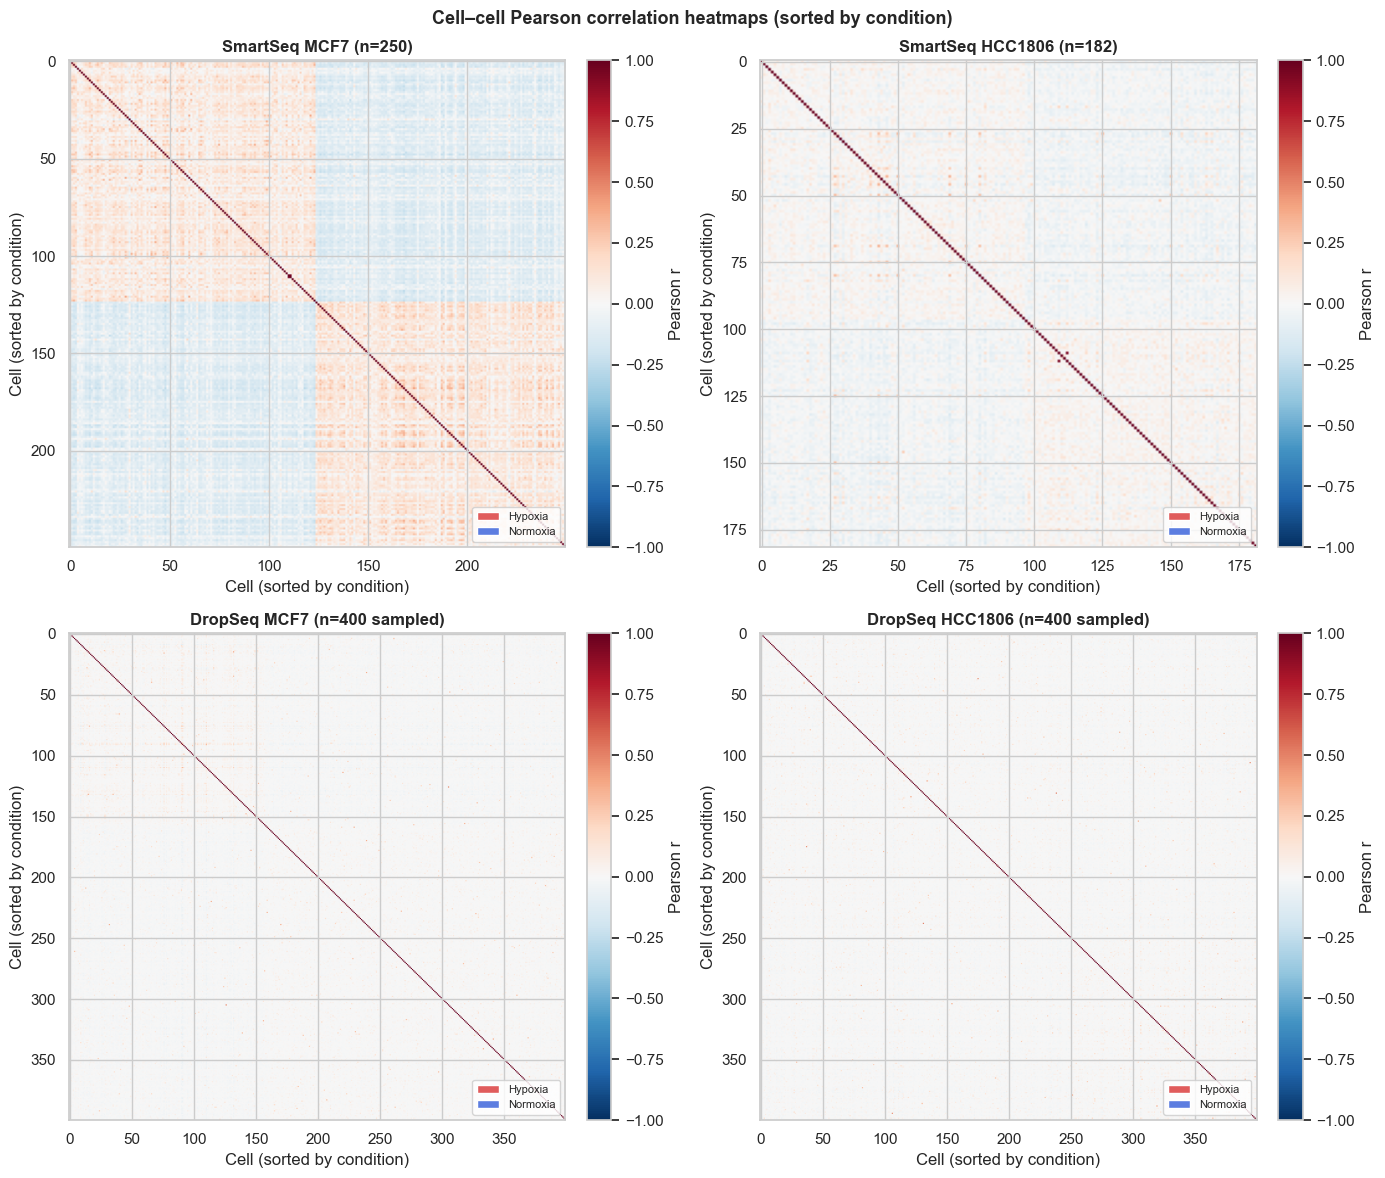

In [35]:
MAX_HEATMAP = 400 #cells to display in heatmap

COND_COL = {'Hypoxia': '#e05c5c', 'Normoxia': '#5c7de0'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, ((tech, line), X) in zip(axes, X_dict.items()):
    conds = cond_dict[(tech, line)]

    if X.shape[0] > MAX_HEATMAP:
        idx = RNG.choice(X.shape[0], MAX_HEATMAP, replace=False)
        X_s, c_s = X[idx], conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        X_s, c_s = X, conds
        note = f'n={X.shape[0]}'

    order = np.argsort(c_s, kind='stable')
    X_s, c_s = X_s[order], c_s[order]

    corr = np.corrcoef(X_s)

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

    ax.set_title(f'{tech} {line} ({note})', fontweight='bold')
    ax.set_xlabel('Cell (sorted by condition)')
    ax.set_ylabel('Cell (sorted by condition)')

    legend_elems = [mpatches.Patch(facecolor=COND_COL['Hypoxia'],  label='Hypoxia'), mpatches.Patch(facecolor=COND_COL['Normoxia'], label='Normoxia')]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=8)

fig.suptitle('Cell–cell Pearson correlation heatmaps (sorted by condition)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation

**What the plot shows:**
Each heatmap is a grid where colour at position (i, j) = how similar cell i is to cell j across all 3,000 genes (red = similar, blue = different, white = no relationship). Cells are sorted Hypoxia first, then Normoxia.

**Results:**
- **SmartSeq MCF7:** Clear block-diagonal. Hypoxia cells are similar to each other (red top-left block), Normoxia cells are similar to each other (red bottom-right block), and the two conditions are dissimilar to each other (blue off-diagonal).
- **SmartSeq HCC1806:** Same pattern but weaker. The bright red dots between row/column 100 and 125 are the 4 outlier cells flagged in Section 3.1.
- **DropSeq:** Nearly no visible structure (r close to 0). Not because the biology is absent, but because DropSeq cells have so many zero counts (dropout) that correlations collapse toward zero regardless of condition.

The block structure confirms that the hypoxia response is the dominant driver of cell-to-cell expression differences.

#### 4.3.1 Flag outlier cells

A cell is an outlier if its mean Pearson correlation with all other cells is more than 3 standard deviations below the dataset mean.  

In [36]:
SD_THRESHOLD = 3.0
outlier_rows = []

for (tech, line), X in X_dict.items():
    corr = np.corrcoef(X)
    np.fill_diagonal(corr, np.nan) #exclude self-correlation
    mean_corr = np.nanmean(corr, axis=1) #mean correlation of each cell vs all others

    mu, sd = np.nanmean(mean_corr), np.nanstd(mean_corr)
    threshold = mu - SD_THRESHOLD * sd
    outlier_mask = mean_corr < threshold

    col_names = datasets[(tech, line)].columns
    n_out = outlier_mask.sum()
    print(f"{tech:10s} {line:8s}: μ={mu:.3f}, σ={sd:.3f}, threshold={threshold:.3f} → {n_out} outlier(s)")

    for idx in np.where(outlier_mask)[0]:
        outlier_rows.append({'Technology': tech, 'Cell line': line,
                              'Cell': col_names[idx],
                              'Mean corr': round(float(mean_corr[idx]), 4),
                              'Threshold': round(float(threshold), 4)})

outlier_df = pd.DataFrame(outlier_rows)
print()
if outlier_df.empty:
    print('No outliers detected across all datasets.')
else:
    print(outlier_df.to_string(index=False))

SmartSeq   MCF7    : μ=-0.004, σ=0.004, threshold=-0.015 → 0 outlier(s)
SmartSeq   HCC1806 : μ=-0.005, σ=0.003, threshold=-0.014 → 4 outlier(s)
DropSeq    MCF7    : μ=0.000, σ=0.002, threshold=-0.005 → 0 outlier(s)
DropSeq    HCC1806 : μ=-0.000, σ=0.000, threshold=-0.001 → 0 outlier(s)

Technology Cell line                                                               Cell  Mean corr  Threshold
  SmartSeq   HCC1806  output.STAR.PCRPlate3A5_Hypoxia_S75_Aligned.sortedByCoord.out.bam    -0.0152    -0.0141
  SmartSeq   HCC1806  output.STAR.PCRPlate3B3_Hypoxia_S70_Aligned.sortedByCoord.out.bam    -0.0159    -0.0141
  SmartSeq   HCC1806 output.STAR.PCRPlate3C2_Hypoxia_S167_Aligned.sortedByCoord.out.bam    -0.0144    -0.0141
  SmartSeq   HCC1806  output.STAR.PCRPlate3G4_Hypoxia_S73_Aligned.sortedByCoord.out.bam    -0.0157    -0.0141


#### Interpretation

| Dataset | Outliers found |
|---------|---------------|
| SmartSeq MCF7 | 0 |
| SmartSeq HCC1806 | **4** (all in Hypoxia) |
| DropSeq MCF7 | 0 |
| DropSeq HCC1806 | 0 |

**Interpretation:**
- Three datasets are clean. SmartSeq HCC1806 has 4 Hypoxia cells whose mean correlation to all other cells is unusually low (more than 3 SD below average).
- These could be failed cell preparations, cells that didn't respond to hypoxia as strongly, or contamination.
- No outliers in DropSeq because the per-cell correlations are already near zero for everyone (due to dropout), so nothing stands out as unusually low.

### 4.4 Principal Component Analysis (PCA)

PCA rotates the 3 000-dimensional gene-expression space to find the directions of maximum variance.  
Because we z-scored first, every gene contributes equally in terms of scale, so PCs capture biological signal.

For each dataset:
- **Scree plot**: bar chart of variance explained per PC + cumulative curve
- **PC1 vs PC2 scatter**: coloured by Hypoxia / Normoxia to see if PCA separates the two conditions without ever seeing the labels

In [37]:
N_COMPONENTS = 30 #compute top-30 PCs

pca_dict = {} #fitted PCA objects
scores_dict = {} #PCA-transformed coordinates(cells × PCs)

for (tech, line), X in X_dict.items():
    n_comp = min(N_COMPONENTS, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    scores = pca.fit_transform(X)
    pca_dict[(tech, line)] = pca
    scores_dict[(tech, line)] = scores
    total_var = pca.explained_variance_ratio_.sum() * 100

    print(f"{tech:10s} {line:8s}: top-{n_comp} PCs explain {total_var:.1f}% of variance")

SmartSeq   MCF7    : top-30 PCs explain 37.7% of variance
SmartSeq   HCC1806 : top-30 PCs explain 35.2% of variance
DropSeq    MCF7    : top-30 PCs explain 3.1% of variance
DropSeq    HCC1806 : top-30 PCs explain 2.9% of variance


> **Note:** The gap between explained variance for SmartSeq and DropSeq is expected since DropSeq's high dropout spreads variance thinly across thousands of dimensions rather than concentrating it in a few meaningful components.

#### 4.4.1 Scree plots

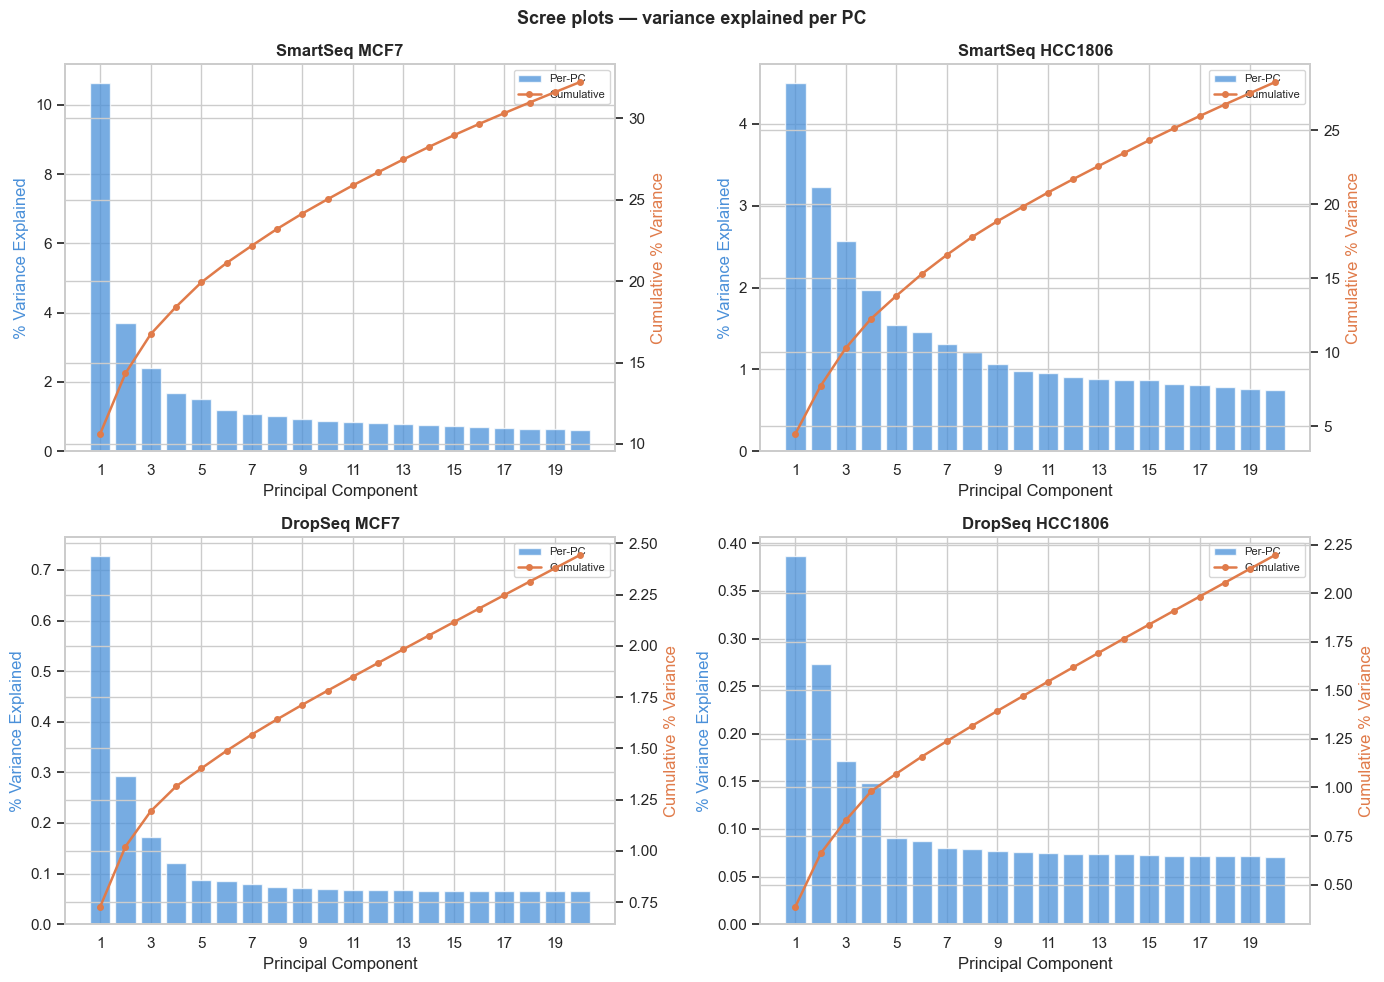

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, ((tech, line), pca) in zip(axes, pca_dict.items()):
    n_show = min(20, len(pca.explained_variance_ratio_))
    ev = pca.explained_variance_ratio_[:n_show] * 100
    cumev = np.cumsum(pca.explained_variance_ratio_) * 100

    ax2 = ax.twinx()
    ax.bar(range(1, n_show + 1), ev, color='#4a90d9', alpha=0.75, label='Per-PC')
    ax2.plot(range(1, n_show + 1), cumev[:n_show], color='#e07b4a', marker='o', ms=4, lw=1.8, label='Cumulative')

    ax.set_xlabel('Principal Component')
    ax.set_ylabel('% Variance Explained', color='#4a90d9')
    ax2.set_ylabel('Cumulative % Variance', color='#e07b4a')
    ax.set_title(f'{tech} {line}', fontweight='bold')
    ax.set_xticks(range(1, n_show + 1, 2))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')

fig.suptitle('Scree plots — variance explained per PC', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation

**What the plot shows:**
Each bar is one PC and its height is how much of the total variance that PC captures alone. The orange line is the running cumulative total. A steep drop after the first few bars (an "elbow") means most of the biological signal is concentrated in just a few dimensions.

**Results:**
| Dataset | Variance explained by top 30 PCs |
|---------|----------------------------------|
| SmartSeq MCF7 | **37.7%** |
| SmartSeq HCC1806 | **35.2%** |
| DropSeq MCF7 | **3.1%** |
| DropSeq HCC1806 | **2.9%** |

**Interpretation:**
- **SmartSeq:** Clear elbow after PC1–PC2, with PC1 alone explaining ~10% (MCF7) and ~4.5% (HCC1806). Most biological signal is captured in the first few components, so the hypoxia response is the dominant axis of variation.
- **DropSeq:** No clear elbow, the bars are all similarly small and the cumulative line rises almost linearly. Only ~3% of variance in 30 PCs. This is the dropout effect: the signal exists but is diluted.

### 4.4.2 PC1 vs PC2 coloured by Hypoxia / Normoxia

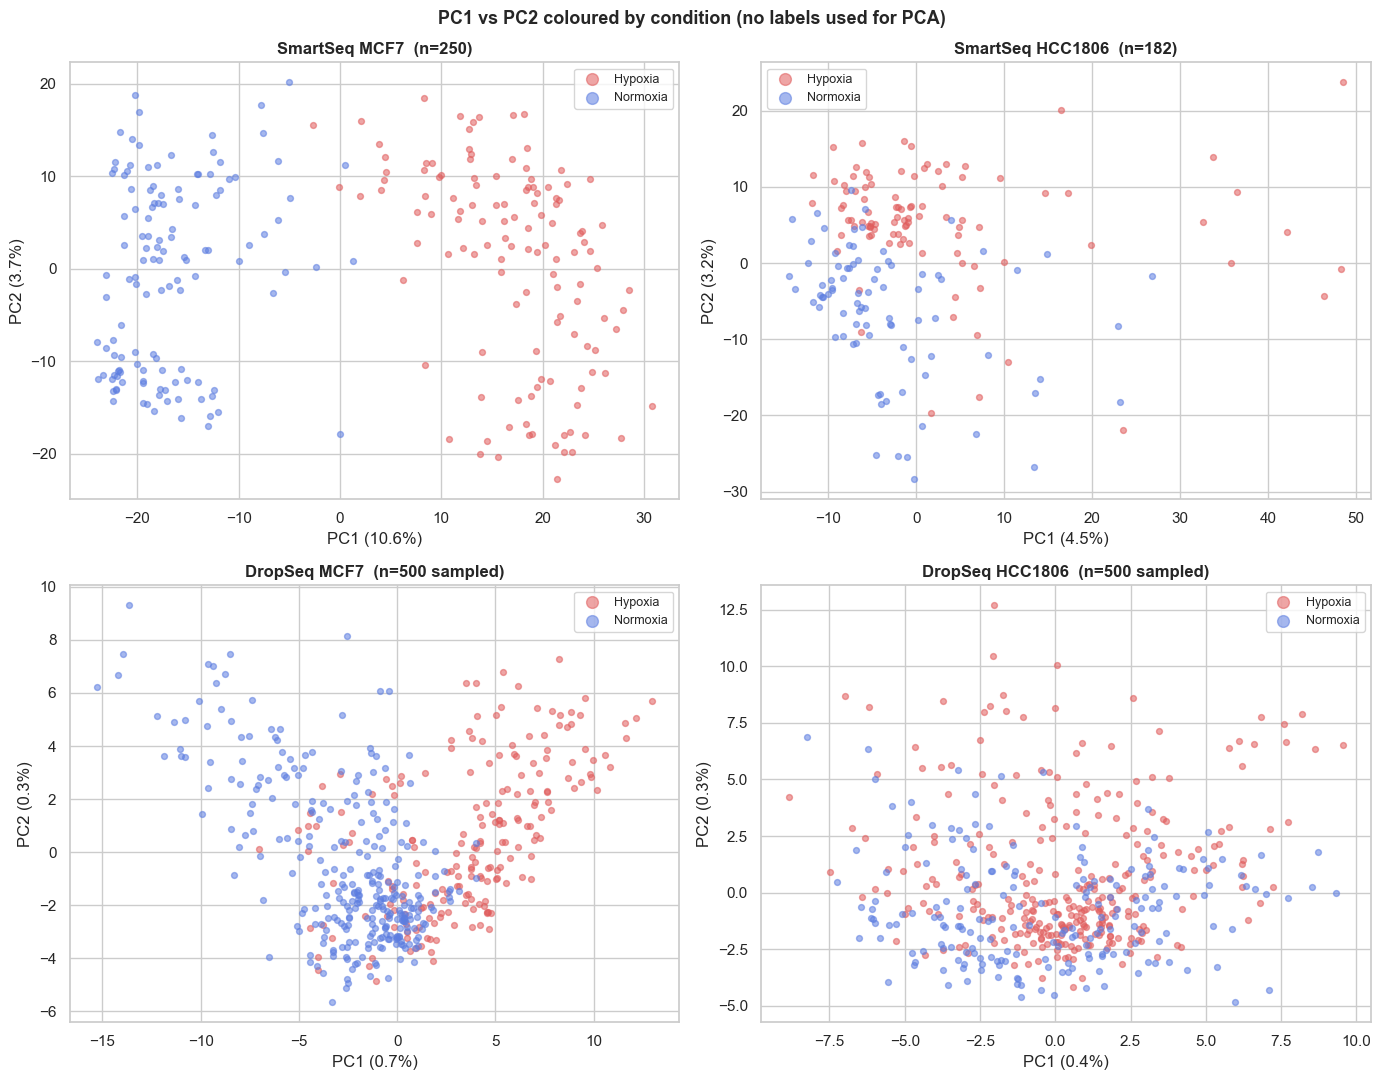

In [39]:
MAX_SCATTER = 500

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, ((tech, line), scores) in zip(axes, scores_dict.items()):
    pca = pca_dict[(tech, line)]
    conds = cond_dict[(tech, line)]

    if scores.shape[0] > MAX_SCATTER:
        idx = RNG.choice(scores.shape[0], MAX_SCATTER, replace=False)
        s_plot = scores[idx, :2]
        c_plot = conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        s_plot, c_plot = scores[:, :2], conds
        note = f'n={scores.shape[0]}'

    for cond, color in COND_COL.items():
        mask = c_plot == cond
        ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, alpha=0.55, s=18, label=cond, rasterized=True)

    ev1 = pca.explained_variance_ratio_[0] * 100
    ev2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f'PC1 ({ev1:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}%)')
    ax.set_title(f'{tech} {line}  ({note})', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('PC1 vs PC2 coloured by condition (no labels used for PCA)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

**What the plot shows:**
Each dot is a cell, plotted by its position on the two most important PCA axes. Colour = condition (red = Hypoxia, blue = Normoxia). PCA never sees the labels, so if the colours separate, it means the biology is doing that, not us.

**Interpretation:**
- **SmartSeq MCF7:** The clearest result, two distinct clouds separated along PC1 (10.6%). PC1 is effectively the Hypoxia/Normoxia axis.
- **SmartSeq HCC1806:** Decent separation but more overlap than MCF7. HCC1806 has a different baseline expression profile (triple-negative vs ER+), so other sources of variation compete with the hypoxia signal along PC1 (4.5%).
- **DropSeq:** Both clouds overlap heavily. Expected: dropout noise drowns out the per-cell signal, and PC1 explains less than 1%. The separation trend is still there but not visually clean.
- **Key message:** Even without labels, PCA separates the two conditions, confirming that hypoxia is the dominant source of variation in these cells.

### 4.5 Clustering

We cluster in PCA-reduced space (top PCs explaining ≥ 80% variance, capped at 10) rather than the full 3 000-gene space. This:
- Reduces noise
- Makes DropSeq clustering computationally feasible

We apply two complementary methods:

| Method | Idea |
|--------|------|
| **K-means** | Assign cells to K clusters minimising within-cluster variance |
| **Hierarchical (Ward)** | Build a tree of merges using Ward linkage |

In [40]:
X_pca = {}
for (tech, line), scores in scores_dict.items():
    X_pca[(tech, line)] = scores[:, :10]
    var_explained = pca_dict[(tech, line)].explained_variance_ratio_[:10].sum() * 100
    print(f"{tech:10s}{line:8s}: using top 10 PCs -> {var_explained:.1f}% variance")

SmartSeq  MCF7    : using top 10 PCs -> 25.0% variance
SmartSeq  HCC1806 : using top 10 PCs -> 19.8% variance
DropSeq   MCF7    : using top 10 PCs -> 1.8% variance
DropSeq   HCC1806 : using top 10 PCs -> 1.5% variance


> **Note:** Since no dataset reaches anywhere near 80% cumulative variance even with 30 PCs, a fixed 80% threshold makes no sense here. We cap at 10 PCs instead, based on the scree plots above, which is enough to capture the strongest biological signal for clustering.

### 3.5.1 Silhouette analysis: choosing the best K for K-means

The silhouette score measures how well each cell fits its own cluster vs the nearest other cluster.  
Range: −1 (wrong cluster) to +1 (perfectly assigned). We pick the K with the highest score.

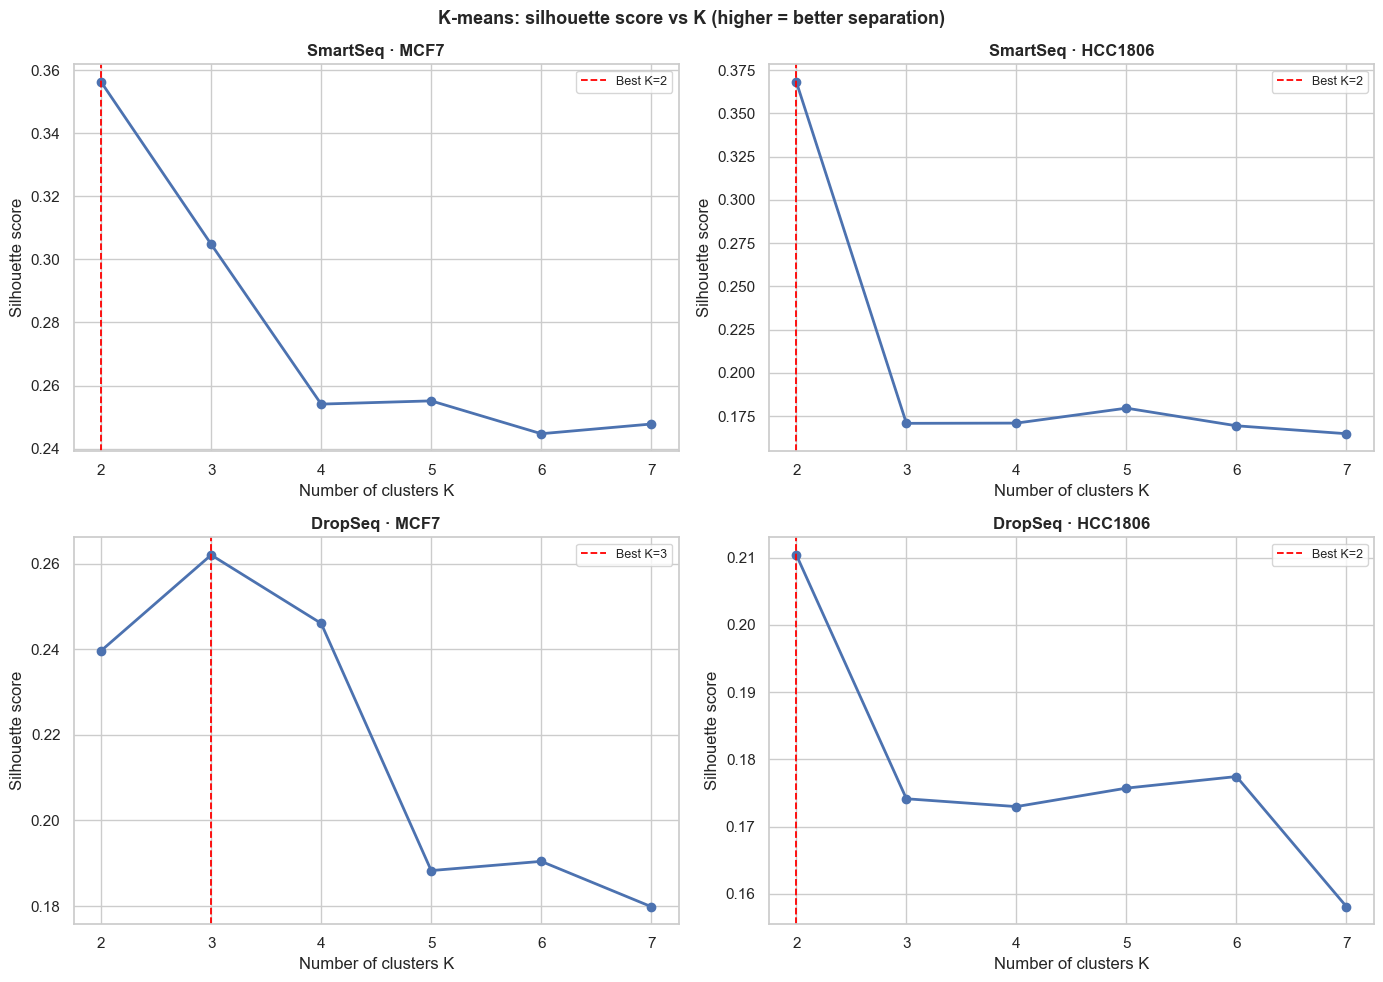

In [41]:
K_RANGE   = range(2, 8)
SIL_CAP   = 3000
sil_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (tech, line) in zip(axes, X_pca.keys()):
    X_cl = X_pca[(tech, line)]
    scores = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_cl)

        if X_cl.shape[0] > SIL_CAP:
            idx_s = RNG.choice(X_cl.shape[0], SIL_CAP, replace=False)
            sil = silhouette_score(X_cl[idx_s], labels[idx_s])
        else:
            sil = silhouette_score(X_cl, labels)
        scores.append(sil)

    sil_results[(tech, line)] = scores
    best_k = list(K_RANGE)[np.argmax(scores)]

    ax.plot(list(K_RANGE), scores, marker='o', lw=2)
    ax.axvline(best_k, color='red', ls='--', lw=1.3, label=f'Best K={best_k}')
    ax.set_xlabel('Number of clusters K')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'{tech} · {line}', fontweight='bold')
    ax.set_xticks(list(K_RANGE))
    ax.legend(fontsize=9)

fig.suptitle('K-means: silhouette score vs K (higher = better separation)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### Interpretation

**What the plot shows:**
Each line shows how silhouette score changes as we try different numbers of clusters (K=2 to 7). Higher = better. The red dashed line marks the winning K.

**Interpretation:**
- **SmartSeq MCF7 and HCC1806:** Both peak sharply at K=2 then drop off. The data strongly prefers two clusters, which aligns perfectly with the two biological conditions (Hypoxia/Normoxia). Scores of ~0.36–0.37 are in the moderate-good range.
- **DropSeq HCC1806:** Also peaks at K=2 but with a much lower score (~0.20) and a flatter curve. The algorithm finds two groups but they are not well-separated, again due to dropout noise.
- **DropSeq MCF7:** The one exception. Peaks at K=3 instead of K=2. This could mean there is a genuine sub-population within one condition (e.g. cells at different stages of hypoxia response), or it could simply be noise creating an extra cluster. Either way, K=2 is still biologically motivated and only marginally worse here.
- **Key message:** Three out of four datasets independently select K=2, matching the known biology without ever seeing the labels.

#### 4.5.2 K-means clusters visualised in PCA space

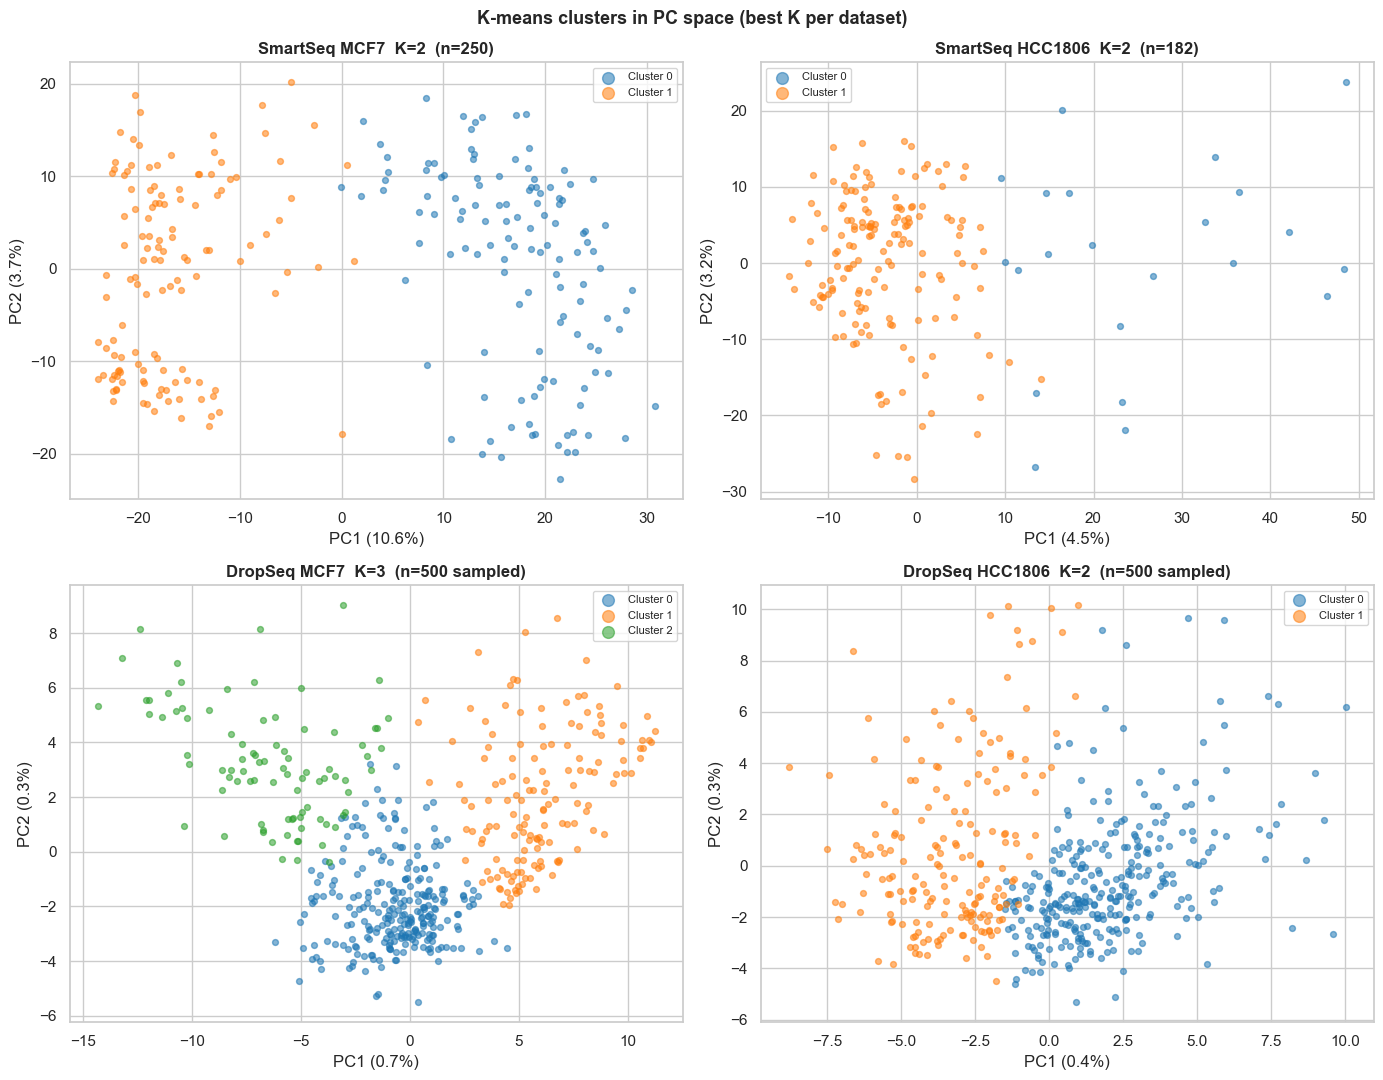

In [42]:
km_labels = {}
best_k_dict = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, ((tech, line), X_cl) in zip(axes, X_pca.items()):
    pca = pca_dict[(tech, line)]
    scores = scores_dict[(tech, line)]
    conds = cond_dict[(tech, line)]

    best_k = list(K_RANGE)[np.argmax(sil_results[(tech, line)])]
    best_k_dict[(tech, line)] = best_k

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl)
    km_labels[(tech, line)] = labels

    if scores.shape[0] > MAX_SCATTER:
        idx = RNG.choice(scores.shape[0], MAX_SCATTER, replace=False)
        s_plot = scores[idx, :2]
        l_plot = labels[idx]
        note = f'n={len(idx)} sampled'
    else:
        s_plot, l_plot = scores[:, :2], labels
        note = f'n={scores.shape[0]}'

    palette = plt.cm.tab10.colors
    for cl in range(best_k):
        mask = l_plot == cl
        ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=palette[cl], alpha=0.55, s=18, label=f'Cluster {cl}', rasterized=True)

    ev1 = pca.explained_variance_ratio_[0] * 100
    ev2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f'PC1 ({ev1:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}%)')
    ax.set_title(f'{tech} {line}  K={best_k}  ({note})', fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle('K-means clusters in PC space (best K per dataset)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### 4.5.3 Cluster vs condition contingency table

How much do the unsupervised K-means clusters align with the Hypoxia/Normoxia labels?  

In [43]:
for (tech, line), labels in km_labels.items():
    conds = cond_dict[(tech, line)]
    ct = pd.crosstab(pd.Series(labels, name='K-means cluster'), pd.Series(conds, name='Condition'))
    ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
    print(f"\n{'-'*55}")
    print(f"{tech} {line}(K={best_k_dict[(tech, line)]})")
    print(ct)
    print("Row % (how much of each cluster is Hypoxia vs Normoxia):")
    print(ct_pct)


-------------------------------------------------------
SmartSeq MCF7(K=2)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                    123         0
1                      1       126
Row % (how much of each cluster is Hypoxia vs Normoxia):
Condition        Hypoxia  Normoxia
K-means cluster                   
0                  100.0       0.0
1                    0.8      99.2

-------------------------------------------------------
SmartSeq HCC1806(K=2)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                     15         7
1                     82        78
Row % (how much of each cluster is Hypoxia vs Normoxia):
Condition        Hypoxia  Normoxia
K-means cluster                   
0                   68.2      31.8
1                   51.2      48.8

-------------------------------------------------------
DropSeq MCF7(K=3)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                   2608  

### Interpretation

**What the tables shows:**
How many cells from each condition (Hypoxia/Normoxia) ended up in each K-means cluster. If the clusters match the biology, each cluster should be dominated by one condition.

**Results:**
- **SmartSeq MCF7 (K=2):** Near-perfect match. Cluster 0 is 100% Hypoxia, cluster 1 is 99.2% Normoxia. Only 1 cell out of 250 was misassigned. K-means recovered the biology almost perfectly without ever seeing the labels.
- **SmartSeq HCC1806 (K=2):** Much weaker. Cluster 0 is 68% Hypoxia, cluster 1 is roughly 50/50. The algorithm finds two groups but they don't map cleanly onto the two conditions. Consistent with the messier PCA separation we saw earlier.
- **DropSeq MCF7 (K=3):** Cluster 1 is mostly Hypoxia (97.2%), but clusters 0 and 2 are both mostly Normoxia. The algorithm split Normoxia into two groups rather than finding a meaningful third biological class.
- **DropSeq HCC1806 (K=2):** Both clusters are mixed (~68/32 and ~48/52). No meaningful separation. The noise overwhelms the signal.

**Key message:** The quality of clustering degrades as data quality decreases. SmartSeq MCF7 is almost perfect, SmartSeq HCC1806 is partial, DropSeq is essentially random. This mirrors everything we've seen so far and confirms that the hypoxia signal is real but technology-dependent in how cleanly it can be recovered.

#### 4.5.4 Hierarchical clustering (Ward linkage) + dendrograms

Hierarchical clustering builds a tree of cell merges bottom-up. Ward linkage minimises the total within-cluster variance at each merge.

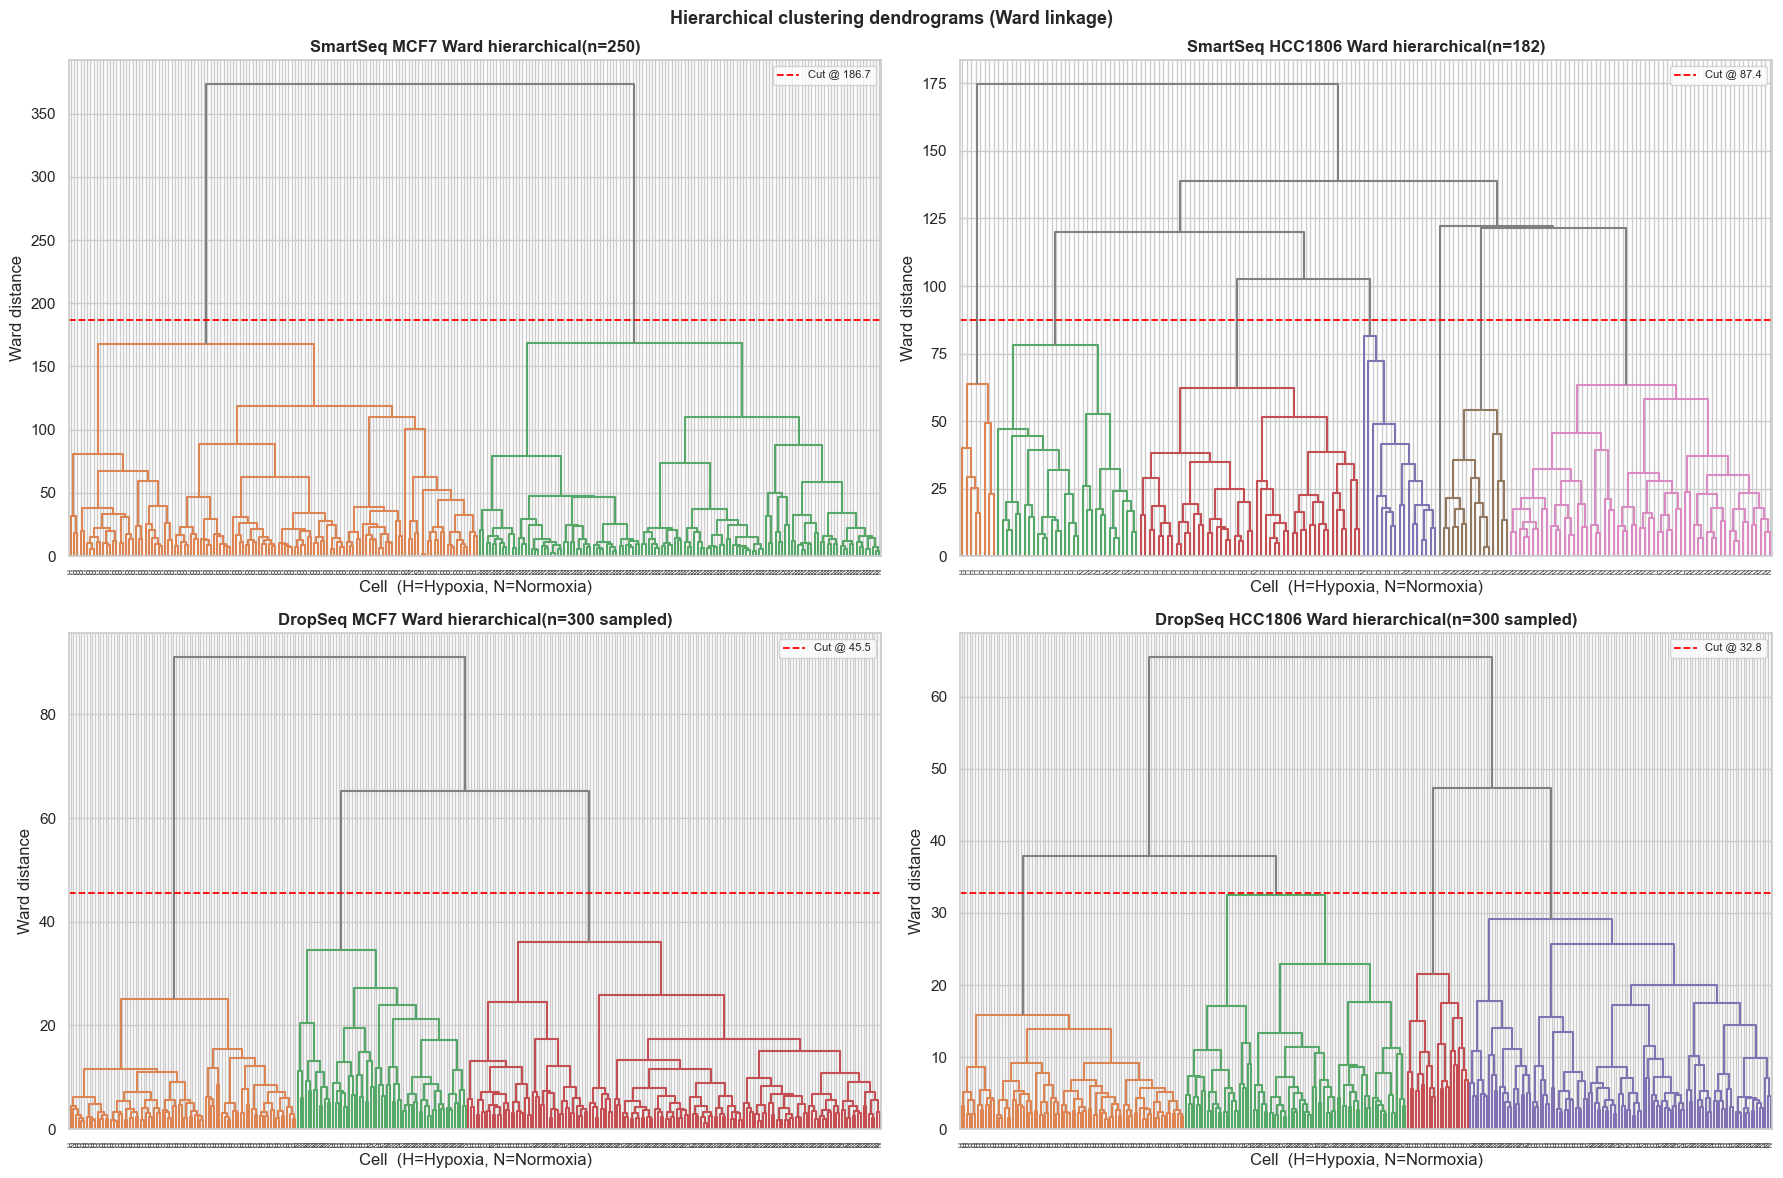

In [44]:
DENDRO_CAP = 300
hc_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, ((tech, line), X_cl) in zip(axes, X_pca.items()):
    conds = cond_dict[(tech, line)]
    best_k = best_k_dict[(tech, line)]

    if X_cl.shape[0] > DENDRO_CAP:
        idx = RNG.choice(X_cl.shape[0], DENDRO_CAP, replace=False)
        X_den = X_cl[idx]
        c_den = conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        X_den, c_den = X_cl, conds
        note = f'n={X_cl.shape[0]}'

    Z = linkage(X_den, method='ward')
    color_thresh = 0.5 * Z[-1, 2] #cutoff at 50% of the max merge distance

    leaf_labels = ['H' if c == 'Hypoxia' else 'N' for c in c_den]
    dendrogram(Z, ax=ax, labels=leaf_labels, color_threshold=color_thresh, leaf_rotation=90, leaf_font_size=5, above_threshold_color='grey')

    ax.axhline(color_thresh, color='red', ls='--', lw=1.3, label=f'Cut @ {color_thresh:.1f}')
    ax.set_title(f'{tech} {line} Ward hierarchical({note})', fontweight='bold')
    ax.set_xlabel('Cell  (H=Hypoxia, N=Normoxia)')
    ax.set_ylabel('Ward distance')
    ax.legend(fontsize=8)

    hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
    hc_labels[(tech, line)] = hc.fit_predict(X_cl)

fig.suptitle('Hierarchical clustering dendrograms (Ward linkage)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation

**What the plot shows:**
A dendrogram is a tree where each cell starts as its own leaf at the bottom and the algorithm progressively merges the most similar pairs upward. The height of each merge (y-axis = Ward distance) tells you how different the two groups being joined were. A high final merge means the last two groups were very distinct. The red dashed line is fixed at 50% of the maximum merge distance, acting as a threshold: if the two main branches are already clearly formed below that line, the data has clean two-group structure.

**Interpretation:**
- **SmartSeq MCF7:** One dominant split very high up. The two main branches are fully formed well below the red line, meaning the two groups are genuinely distinct. The dendrogram clearly supports K=2.
- **SmartSeq HCC1806 and DropSeq:** The tree fragments into many smaller branches at similar heights rather than two dominant ones. The red line cuts through a messy region rather than cleanly between two big branches, consistent with the weaker separation we've seen throughout: lower silhouette scores, overlapping PCA clouds, and mixed contingency tables.
- **Key message:** The dendrogram is most informative for SmartSeq MCF7, where the clean two-branch structure visually confirms the biology. For the noisier datasets it is less conclusive, but that itself is consistent with everything else we've found. Both hierarchical and K-means agree on K=2 for three out of four datasets, which makes the result more trustworthy regardless.

### 4.5.5 Silhouette score summary table: K-means vs Hierarchical

In [45]:
summary_rows = []

for (tech, line), X_cl in X_pca.items():
    best_k = best_k_dict[(tech, line)]

    if X_cl.shape[0] > SIL_CAP:
        idx_s = RNG.choice(X_cl.shape[0], SIL_CAP, replace=False)
    else:
        idx_s = np.arange(X_cl.shape[0])

    sil_km = silhouette_score(X_cl[idx_s], km_labels[(tech, line)][idx_s])
    sil_hc = silhouette_score(X_cl[idx_s], hc_labels[(tech, line)][idx_s])

    summary_rows.append({
        'Technology': tech, 'Cell line': line, 'K': best_k,
        'Silhouette K-means': round(sil_km, 4),
        'Silhouette Hierarchical': round(sil_hc, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Technology Cell line  K  Silhouette K-means  Silhouette Hierarchical
  SmartSeq      MCF7  2              0.3562                   0.3498
  SmartSeq   HCC1806  2              0.3682                   0.4586
   DropSeq      MCF7  3              0.2589                   0.2064
   DropSeq   HCC1806  2              0.2060                   0.1671


### Interpretation

| Dataset | Best K | Silhouette K-means | Silhouette Hierarchical |
|---------|--------|--------------------|-------------------------|
| SmartSeq · MCF7 | 2 | 0.356 | 0.350 |
| SmartSeq · HCC1806 | 2 | 0.368 | 0.459 |
| DropSeq · MCF7 | 3 | 0.271 | 0.214 |
| DropSeq · HCC1806 | 2 | 0.207 | 0.171 |

**Interpretation:**
- **SmartSeq** scores (~0.35–0.46) are above the 0.3 threshold for meaningful cluster structure. Both methods agree on K=2, consistent with everything we've seen.
- **DropSeq** scores (~0.17–0.27) are weaker but not zero. The biological signal is there but partially drowned out by dropout noise.
- **K-means and hierarchical give similar scores across all four datasets**, which is reassuring. Two different algorithms reaching the same conclusion reduces the chance it's a coincidence or a quirk of one method.
- **Bottom line:** Cluster quality tracks data quality. SmartSeq separates cleanly, DropSeq less so, exactly the pattern we've seen throughout every section of this analysis.

## 4.6. Cross-dataset comparison

We compare the unsupervised structure along two axes:

**Axis 1: Cell line:** MCF7 vs HCC1806 within the same sequencing technology.  
**Axis 2: Technology:** SmartSeq vs DropSeq for the same cell line.

Since each dataset has its own PCA space (fitted on its own genes), we overlay the PC1–PC2 scatter plots side by side. The absolute coordinates differ, but we can compare the degree of separation between Hypoxia and Normoxia.

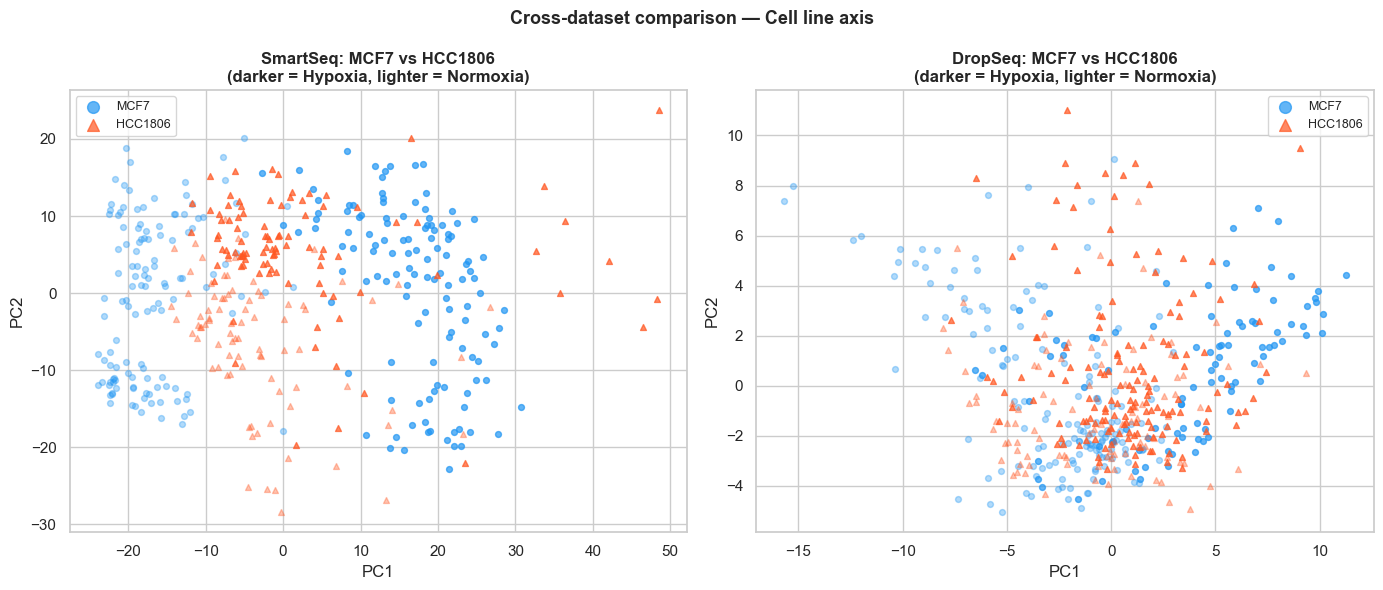

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tech in zip(axes, ['SmartSeq', 'DropSeq']):
    for line, marker, color in [('MCF7', 'o', '#2196F3'), ('HCC1806', '^', '#FF5722')]:
        scores = scores_dict[(tech, line)]
        conds  = cond_dict[(tech, line)]

        if scores.shape[0] > MAX_SCATTER // 2:
            idx = RNG.choice(scores.shape[0], MAX_SCATTER // 2, replace=False)
            s_plot = scores[idx, :2]
            c_plot = conds[idx]
        else:
            s_plot, c_plot = scores[:, :2], conds

        for cond, alpha in [('Hypoxia', 0.7), ('Normoxia', 0.35)]:
            mask = c_plot == cond
            lbl = f'{line}' if cond == 'Hypoxia' else None
            ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, marker=marker, alpha=alpha, s=18, label=lbl, rasterized=True)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{tech}: MCF7 vs HCC1806\n(darker = Hypoxia, lighter = Normoxia)', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('Cross-dataset comparison — Cell line axis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation

**What the plot shows:**
Both cell lines are overlaid on the same PCA axes at once: blue circles = MCF7, orange triangles = HCC1806, darker shade = Hypoxia, lighter = Normoxia.

**Interpretation:**
- **SmartSeq:** The two clouds overlap but don't sit on top of each other. MCF7 and HCC1806 occupy somewhat different regions of PCA space, reflecting their different baseline expression profilesù. Within each cloud, the dark/light shade separation is visible, confirming the hypoxia signal exists in both cell lines.
- **DropSeq:** Both clouds are heavily mixed and largely overlapping. The noise overwhelms any cell-line separation, consistent with everything we've seen for DropSeq throughout.
- **Key message:** The two cell lines have different enough baseline expression that a classifier trained on one may not transfer cleanly to the other. The PCA space shifts between them. However the hypoxia response is present in both, just from different starting points.

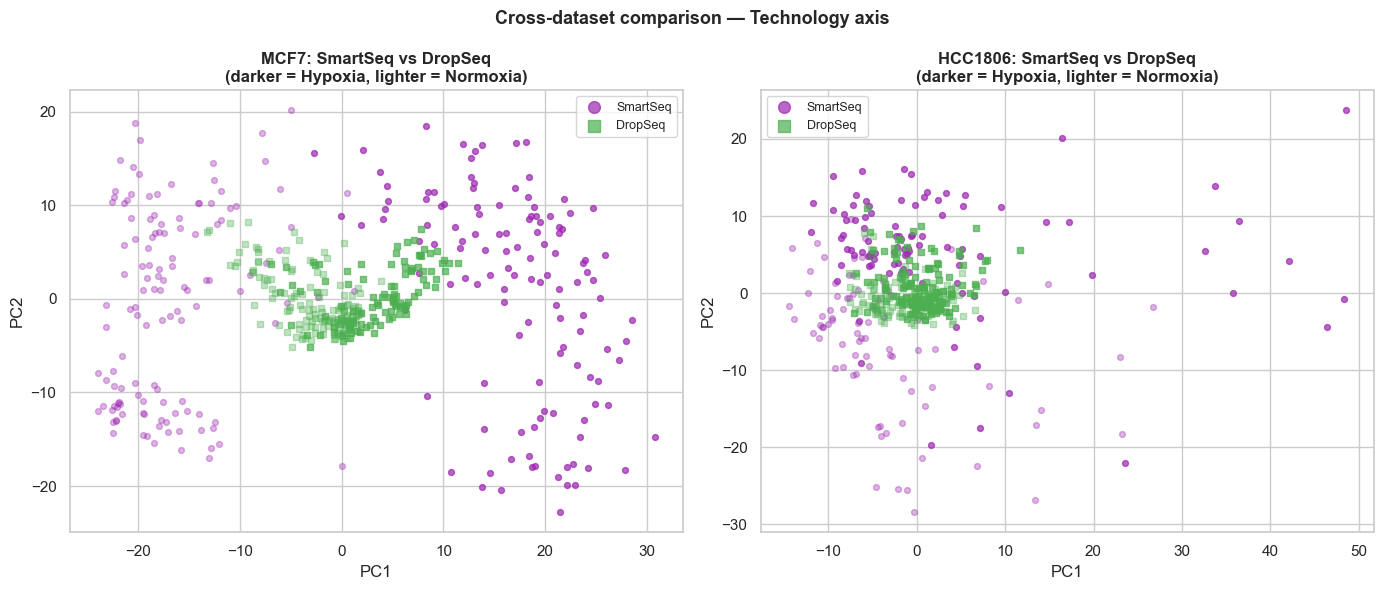

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, line in zip(axes, ['MCF7', 'HCC1806']):
    for tech, marker, color in [('SmartSeq', 'o', '#9C27B0'), ('DropSeq', 's', '#4CAF50')]:
        scores = scores_dict[(tech, line)]
        conds = cond_dict[(tech, line)]

        if scores.shape[0] > MAX_SCATTER // 2:
            idx = RNG.choice(scores.shape[0], MAX_SCATTER // 2, replace=False)
            s_plot = scores[idx, :2]
            c_plot = conds[idx]
        else:
            s_plot, c_plot = scores[:, :2], conds

        for cond, alpha in [('Hypoxia', 0.7), ('Normoxia', 0.35)]:
            mask = c_plot == cond
            lbl = f'{tech}' if cond == 'Hypoxia' else None
            ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, marker=marker, alpha=alpha, s=18, label=lbl, rasterized=True)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{line}: SmartSeq vs DropSeq\n(darker = Hypoxia, lighter = Normoxia)', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('Cross-dataset comparison — Technology axis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

**What the plot shows:**
Same cell line, two technologies overlaid: purple = SmartSeq, green = DropSeq, darker shade = Hypoxia, lighter = Normoxia. This asks whether the two technologies produce a compatible view of the same biology.

**Interpretation:**
- **SmartSeq** cells are spread out widely across both axes with clear dark/light separation. Deep sequencing produces distinct profiles that PCA can spread apart cleanly.
- **DropSeq** cells are compressed into a tight cluster near the centre. Shallow sequencing with high dropout produces flat, similar-looking profiles that PCA can't spread out as much.
- Despite this, both technologies show the same directional trend for Hypoxia vs Normoxia. The hypoxia signal points the same way regardless of technology.
- **Key message:** The hypoxia signal is robust. SmartSeq gives a cleaner picture, DropSeq a noisier one, but both are capturing the same underlying biology.

> **Note:** each dataset's PCA was fit independently, so the PC1/PC2 axes are not the same across datasets. Points from different datasets are not directly comparable in magnitude, only the within-dataset separation patterns should be interpreted.

### 4.7. Results summary and interpretation

#### Correlation Heatmaps
The SmartSeq MCF7 heatmap shows a clear block-diagonal structure. Hypoxia cells are similar to each other, Normoxia cells are similar to each other, and the two conditions are dissimilar to each other. This confirms that hypoxia is the dominant driver of cell-to-cell expression differences, not noise or batch effects. SmartSeq HCC1806 shows the same pattern but weaker. DropSeq heatmaps are flat due to dropout, not because the biology is absent, but because per-cell correlations collapse toward zero when most gene values are zero. The 4 outlier cells flagged in SmartSeq HCC1806 should be reviewed before classifier training.

#### PCA Scree Plots
SmartSeq shows a clear elbow after PC1–PC2, with PC1 alone explaining 10.6% (MCF7) and 4.5% (HCC1806) of variance. The hypoxia response is concentrated in the first few components. DropSeq shows no elbow and only ~3% variance in the top 30 PCs, dropout spreads variance thinly across thousands of dimensions. All four datasets hit the 10 PC cap before reaching 80% variance, so clustering uses the top 10 PCs throughout.

#### PC1 vs PC2 Scatter
SmartSeq MCF7 shows the clearest separation: two distinct clouds along PC1, with PCA recovering the Hypoxia/Normoxia split without ever seeing the labels. SmartSeq HCC1806 shows good but messier separation. DropSeq shows heavy overlap due to noise, though a directional trend is still visible. The key message: the hypoxia signal is the dominant source of variation in these cells, which predicts that classifiers will have a strong signal to learn from.

#### Clustering
K=2 was the optimal number of clusters in three out of four datasets, matching the two biological conditions. SmartSeq MCF7 was near-perfect: 249 out of 250 cells correctly grouped without labels. SmartSeq HCC1806 was partial. DropSeq results were weak due to noise, with DropSeq MCF7 preferring K=3, likely a noise artefact rather than a genuine third biological group. Silhouette scores ranged from 0.35–0.46 for SmartSeq (meaningful structure) and 0.17–0.27 for DropSeq (weak but non-zero). Both K-means and hierarchical clustering agreed across all four datasets, making the findings more trustworthy.

#### Cross-Dataset Comparison
**Cell-line axis (MCF7 vs HCC1806):** The two cell lines occupy different regions of PCA space, their baseline expression profiles are biologically distinct (MCF7 = ER+ luminal, HCC1806 = triple-negative basal). However the hypoxia response is present in both, just from different starting points. This means a classifier trained on one cell line may not transfer directly to the other.

**Technology axis (SmartSeq vs DropSeq):** SmartSeq cells are spread wide and well-separated, DropSeq cells compress into a tight cluster near the centre. Despite this, both technologies show the hypoxia signal pointing in the same direction. The biology is robust even if the clarity is not.

## 5. Supervised learning

### 5.1 Introduction

This section trains and evaluates supervised classifiers for hypoxia detection on two DropSeq datasets: **MCF7** and **HCC1806**. We will be running both cell lines in parallel at each step so results can be compared directly.

Supervised classification focuses *only* on DropSeq, as the unsupervised analysis demonstrated that SmartSeq data separates almost perfectly without labels (SmartSeq MCF7 K-means: 249/250 correctly grouped, as shown in section 4.5.3), making supervised classification on SmartSeq an uninteresting baseline.

The two lines were profiled under identical conditions (Hypoxia / Normoxia) but differ in subtype, baseline expression, and hypoxia exposure time (72h for MCF7, 24h for HCC1806). From the unsupervised analysis we already know that MCF7 shows a cleaner hypoxia signal than HCC1806 in DropSeq data. The aim here is to quantify that difference in a supervised setting and check whether it holds across all four classifiers.

**Pipeline per cell line (run in parallel):**
1. Load DropSeq train / anonymous test matrices
2. Extract Hypoxia / Normoxia labels from cell barcodes
3. Feature selection: variance threshold -> top-500 mutual information genes
4. 5-fold stratified cross-validation (LR, SVM-RBF, RF, GBM)
5. Train on the full training set and serialise models
6. Predict on the anonymous test set
7. Random Forest feature importance
8. Cross-line comparison of CV accuracy and top genes

In [48]:
LINES = ['MCF7', 'HCC1806']
TECHS = ['DropSeq', 'SmartSeq']
KEYS = [('DropSeq', 'MCF7'), ('DropSeq', 'HCC1806'), ('SmartSeq', 'MCF7'), ('SmartSeq', 'HCC1806')]

N_TOP_GENES = 500
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 5.2 Load the necessary files

Each matrix is stored **genes × cells**; we transpose to get the standard **cells × genes** format.

- `train_raw`: labelled cells, where barcode encodes condition (example: `AAAAACCTATCG_Normoxia`)
- `test_raw`: anonymous cells, there is no label, predictions saved at the end


In [49]:
train_raw = {
    ('DropSeq',  'MCF7'):    load_matrix('data/DropSeq/MCF7_Filtered_Normalised_3000_Data_train.txt').T,
    ('DropSeq',  'HCC1806'): load_matrix('data/DropSeq/HCC1806_Filtered_Normalised_3000_Data_train.txt').T,
    ('SmartSeq', 'MCF7'):    load_matrix('data/SmartSeq/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt').T,
    ('SmartSeq', 'HCC1806'): load_matrix('data/SmartSeq/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt').T,
}
test_raw = {
    ('DropSeq',  'MCF7'):    load_matrix('data/DropSeq/MCF7_Filtered_Normalised_3000_Data_test_anonim.txt').T,
    ('DropSeq',  'HCC1806'): load_matrix('data/DropSeq/HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt').T,
    ('SmartSeq', 'MCF7'):    load_matrix('data/SmartSeq/MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt').T,
    ('SmartSeq', 'HCC1806'): load_matrix('data/SmartSeq/HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt').T,
}


for key in KEYS:
    print(f"{key}  train: {train_raw[key].shape}  test: {test_raw[key].shape}")
    print(f"sample barcodes: {train_raw[key].index[:3].tolist()}")

('DropSeq', 'MCF7')  train: (21626, 3000)  test: (5406, 3000)
sample barcodes: ['AAAAACCTATCG_Normoxia', 'AAAACAACCCTA_Normoxia', 'AAAACACTCTCA_Normoxia']
('DropSeq', 'HCC1806')  train: (14682, 3000)  test: (3671, 3000)
sample barcodes: ['AAAAAACCCGGC_Normoxia', 'AAAACCGGATGC_Normoxia', 'AAAACGAGCTAG_Normoxia']
('SmartSeq', 'MCF7')  train: (250, 3000)  test: (63, 3000)
sample barcodes: ['output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam']
('SmartSeq', 'HCC1806')  train: (182, 3000)  test: (45, 3000)
sample barcodes: ['output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam']


### 5.3 Extract Labels

Labels are the last `_`-delimited token in each training barcode. The anonymous test set carries no label.

In [50]:
y_train = {}
x_train = {}
x_test  = {}

for key in KEYS:
    y_train[key] = np.array([get_condition(c) for c in train_raw[key].index])
    x_train[key] = train_raw[key].values
    x_test[key]  = test_raw[key].values
    dist = pd.Series(y_train[key]).value_counts().to_dict()
    print(f"{key}  label distribution: {dist}  |  test cells: {x_test[key].shape[0]}")

('DropSeq', 'MCF7')  label distribution: {'Normoxia': 12705, 'Hypoxia': 8921}  |  test cells: 5406
('DropSeq', 'HCC1806')  label distribution: {'Hypoxia': 8899, 'Normoxia': 5783}  |  test cells: 3671
('SmartSeq', 'MCF7')  label distribution: {'Normoxia': 126, 'Hypoxia': 124}  |  test cells: 63
('SmartSeq', 'HCC1806')  label distribution: {'Hypoxia': 97, 'Normoxia': 85}  |  test cells: 45


### 5.4 Feature selection

Two-stage dimensionality reduction, **fit on train only** to avoid data leakage:

1. **Variance threshold** (`threshold=0.01`): remove near-constant genes.
2. **Mutual information** (`mutual_info_classif`): keep the top `N_TOP_GENES = 500` genes most informative about the Hypoxia/Normoxia label.

The same fitted transformers are applied to the test set without refitting.

In [51]:
var_filter   = {}
x_train_var  = {}
x_test_var   = {}
mi_scores    = {}
top_idx      = {}
top_genes    = {}
x_train_top  = {}
x_test_top   = {}

for key in KEYS:
    # variance filter
    vf = VarianceThreshold(threshold=0.01)
    x_train_var[key] = vf.fit_transform(x_train[key])
    x_test_var[key]  = vf.transform(x_test[key])
    var_filter[key]  = vf
    print(f"{key[0]:10s} {key[1]:8s}  genes before: {x_train[key].shape[1]}  after variance filter: {x_train_var[key].shape[1]}")

    # mutual information
    mi = mutual_info_classif(x_train_var[key], y_train[key], random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][:N_TOP_GENES]
    mi_scores[key] = mi
    top_idx[key]   = idx
    x_train_top[key] = x_train_var[key][:, idx]
    x_test_top[key]  = x_test_var[key][:, idx]

    genes_after_var = train_raw[key].columns[vf.get_support()]
    top_genes[key] = genes_after_var[idx]
    print(f"{key[0]:10s} {key[1]:8s}  genes after MI selection: {x_train_top[key].shape[1]}")

DropSeq    MCF7      genes before: 3000  after variance filter: 1125
DropSeq    MCF7      genes after MI selection: 500
DropSeq    HCC1806   genes before: 3000  after variance filter: 1113
DropSeq    HCC1806   genes after MI selection: 500
SmartSeq   MCF7      genes before: 3000  after variance filter: 3000
SmartSeq   MCF7      genes after MI selection: 500
SmartSeq   HCC1806   genes before: 3000  after variance filter: 3000
SmartSeq   HCC1806   genes after MI selection: 500


#### 5.4.1 Top 20 genes by mutual information: MCF7 vs HCC1806

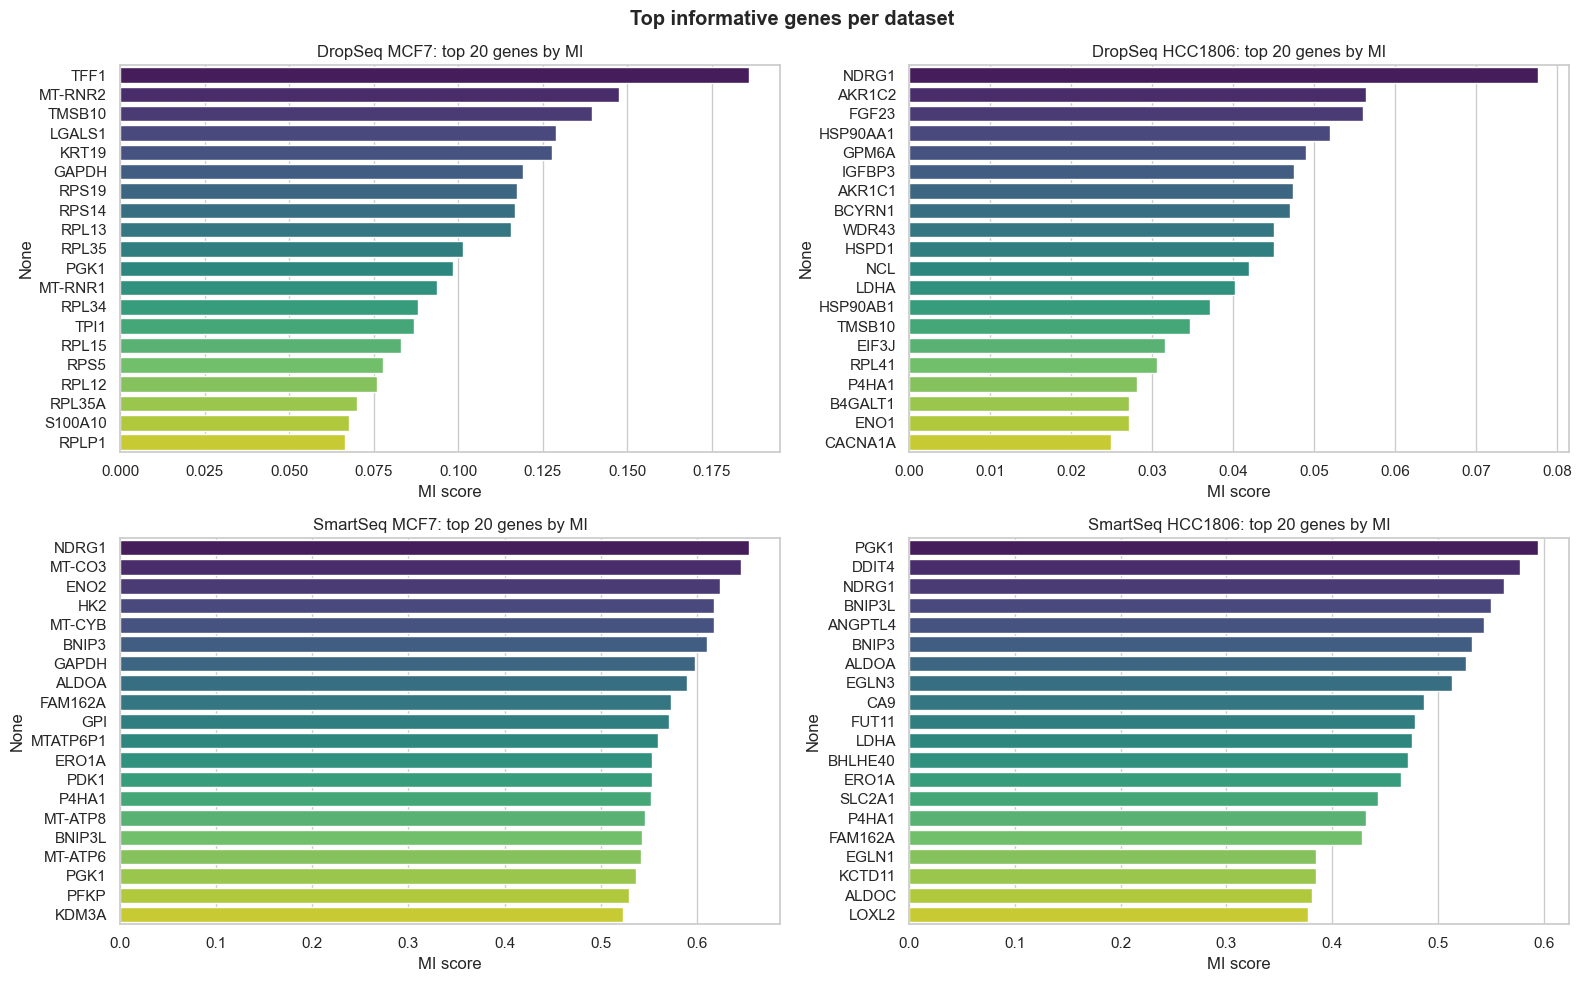

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, key in zip(axes.flat, KEYS):
    sns.barplot(x=mi_scores[key][top_idx[key]][:20], y=top_genes[key][:20], palette='viridis', ax=ax)
    ax.set_title(f'{key[0]} {key[1]}: top 20 genes by MI')
    ax.set_xlabel('MI score')
plt.suptitle('Top informative genes per dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5. Cross-validation

5-fold stratified cross-validation on `x_train_top` for all four classifiers, run independently on each cell line.


In [53]:
models_def = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM':                SVC(kernel='rbf', random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

cv_results = {}
for key in KEYS:
    cv_results[key] = {}
    print(f"\n--- {key[0]} {key[1]} ---")
    for name, model in models_def.items():
        scores = cross_val_score(model, x_train_top[key], y_train[key], cv=cv, scoring='accuracy')
        cv_results[key][name] = scores
        print(f"  {name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}")



--- DropSeq MCF7 ---
  LogisticRegression         mean=0.9767  std=0.0016
  SVM                        mean=0.9807  std=0.0024
  RandomForest               mean=0.9699  std=0.0018
  GradientBoosting           mean=0.9703  std=0.0010

--- DropSeq HCC1806 ---
  LogisticRegression         mean=0.9472  std=0.0021
  SVM                        mean=0.9541  std=0.0022
  RandomForest               mean=0.9318  std=0.0024
  GradientBoosting           mean=0.9313  std=0.0021

--- SmartSeq MCF7 ---
  LogisticRegression         mean=1.0000  std=0.0000
  SVM                        mean=0.9920  std=0.0098
  RandomForest               mean=0.9960  std=0.0080
  GradientBoosting           mean=0.9760  std=0.0150

--- SmartSeq HCC1806 ---
  LogisticRegression         mean=0.9890  std=0.0134
  SVM                        mean=0.9781  std=0.0269
  RandomForest               mean=0.9890  std=0.0134
  GradientBoosting           mean=0.9560  std=0.0377


#### 5.5.1 CV accuracy distribution side by side

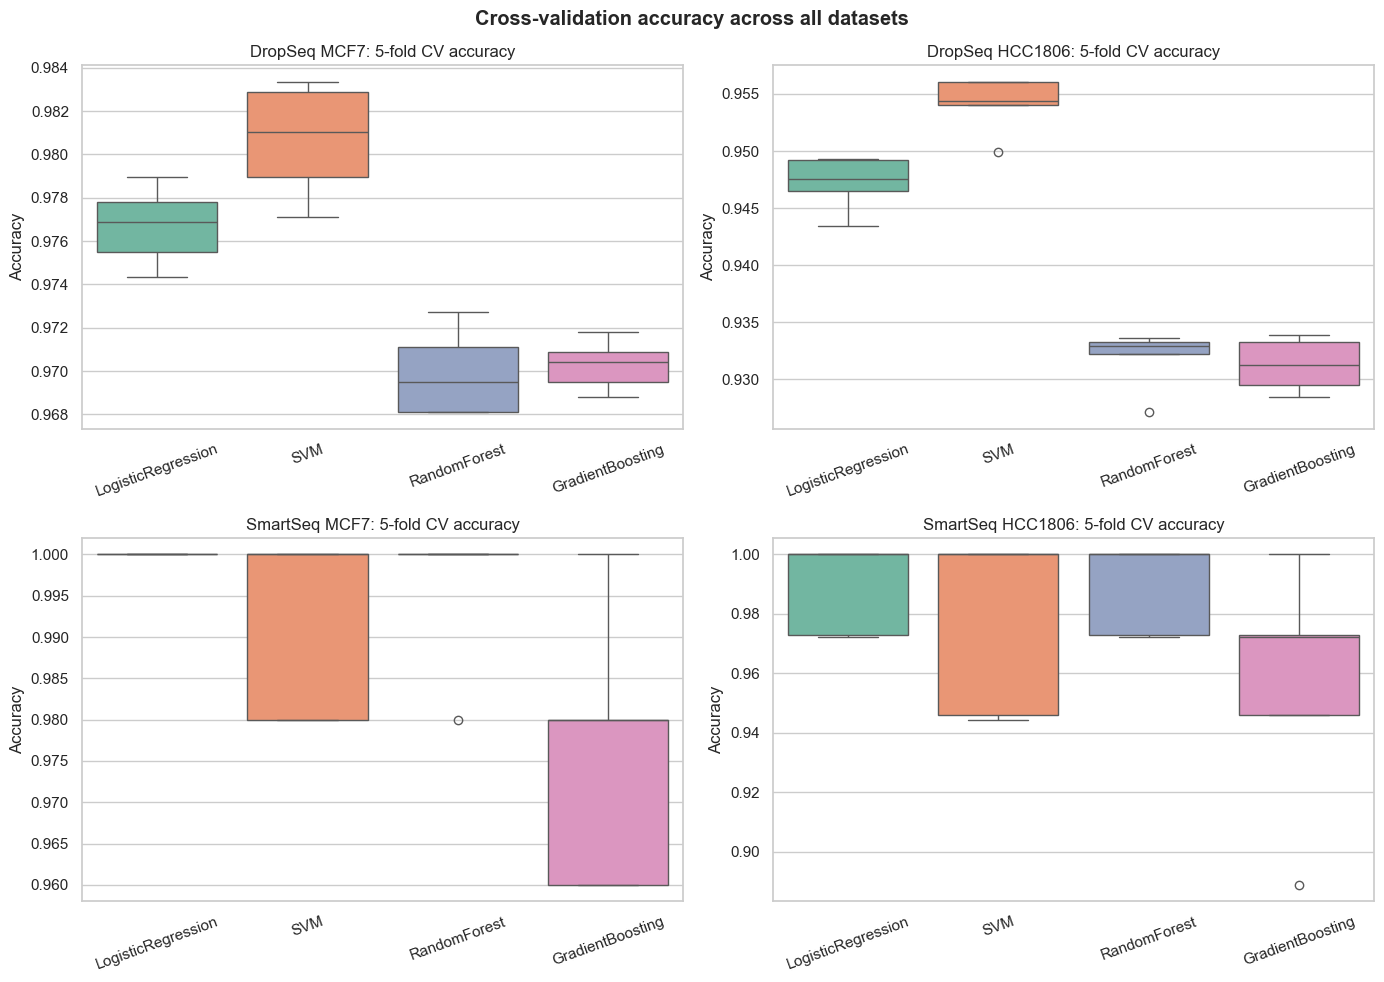

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
for ax, key in zip(axes.flat, KEYS):
    sns.boxplot(data=pd.DataFrame(cv_results[key]), palette='Set2', ax=ax)
    ax.set_title(f'{key[0]} {key[1]}: 5-fold CV accuracy')
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Cross-validation accuracy across all datasets', fontweight='bold')
plt.tight_layout()
plt.show()


#### 5.5.2. Mean CV accuracy: direct comparison table

In [55]:
rows = []
for key in KEYS:
    for name, scores in cv_results[key].items():
        rows.append({'Technology': key[0], 'Cell line': key[1], 'Model': name,
                     'Mean accuracy': round(scores.mean(), 4), 'Std': round(scores.std(), 4)})
cv_table = pd.DataFrame(rows).pivot_table(index='Model', columns=['Technology', 'Cell line'], values='Mean accuracy')
print(cv_table.to_string())


Technology         DropSeq         SmartSeq       
Cell line          HCC1806    MCF7  HCC1806   MCF7
Model                                             
GradientBoosting    0.9313  0.9703   0.9560  0.976
LogisticRegression  0.9472  0.9767   0.9890  1.000
RandomForest        0.9318  0.9699   0.9890  0.996
SVM                 0.9541  0.9807   0.9781  0.992


### 5.6. Training on full set

Each of the 16 models (4 datasets × 4 classifiers) is trained independently on its own dataset's feature-selected training data. For each dataset, a fresh model instance is created via `type(model)(**model.get_params())` to avoid any state leaking between fits, then trained on `x_train_top[key]` — the 500 MI genes selected specifically for that dataset. No information is shared across datasets during training.


In [ ]:
os.makedirs('outputs/models', exist_ok=True)
trained_models = {}
for key in KEYS:
    trained_models[key] = {}
    for name, model in models_def.items():
        m = type(model)(**model.get_params())
        m.fit(x_train_top[key], y_train[key])
        trained_models[key][name] = m
        path = f'outputs/models/{key[0]}_{key[1]}_{name}.pkl'
        with open(path, 'wb') as f:
            pickle.dump(m, f)
        print(f'Saved: {path}')

DropSeq    MCF7      LogisticRegression: trained
DropSeq    MCF7      SVM: trained
DropSeq    MCF7      RandomForest: trained
DropSeq    MCF7      GradientBoosting: trained
DropSeq    HCC1806   LogisticRegression: trained
DropSeq    HCC1806   SVM: trained
DropSeq    HCC1806   RandomForest: trained
DropSeq    HCC1806   GradientBoosting: trained
SmartSeq   MCF7      LogisticRegression: trained
SmartSeq   MCF7      SVM: trained
SmartSeq   MCF7      RandomForest: trained
SmartSeq   MCF7      GradientBoosting: trained
SmartSeq   HCC1806   LogisticRegression: trained
SmartSeq   HCC1806   SVM: trained
SmartSeq   HCC1806   RandomForest: trained
SmartSeq   HCC1806   GradientBoosting: trained


### 5.7. Predict on an anonymous test set

Best model selected by highest mean CV accuracy (SVM-RBF in both lines based on prior runs).

In [57]:
BEST_MODEL_NAME = 'SVM'

for key in KEYS:
    best = trained_models[key][BEST_MODEL_NAME]
    y_pred = best.predict(x_test_top[key])
    pred_df = pd.DataFrame({'cell': test_raw[key].index, 'predicted_label': y_pred})
    out_path = f'outputs/{key[0]}_{key[1]}_predictions.csv'
    pred_df.to_csv(out_path, index=False)
    dist = pd.Series(y_pred).value_counts().to_dict()
    print(f"{key[0]:10s} {key[1]:8s}  predictions: {dist}  | saved: {out_path}")


DropSeq    MCF7      predictions: {'Normoxia': 3242, 'Hypoxia': 2164}  | saved: outputs/DropSeq_MCF7_predictions.csv
DropSeq    HCC1806   predictions: {'Hypoxia': 2202, 'Normoxia': 1469}  | saved: outputs/DropSeq_HCC1806_predictions.csv
SmartSeq   MCF7      predictions: {'Normoxia': 32, 'Hypoxia': 31}  | saved: outputs/SmartSeq_MCF7_predictions.csv
SmartSeq   HCC1806   predictions: {'Normoxia': 24, 'Hypoxia': 21}  | saved: outputs/SmartSeq_HCC1806_predictions.csv


### 5.8. Random Forest feature importance

RF `feature_importances_` (mean decrease in impurity) is complementary to the MI scores from 5.5.: MI measures marginal relevance to the label; RF importance reflects contribution within the trained ensemble.


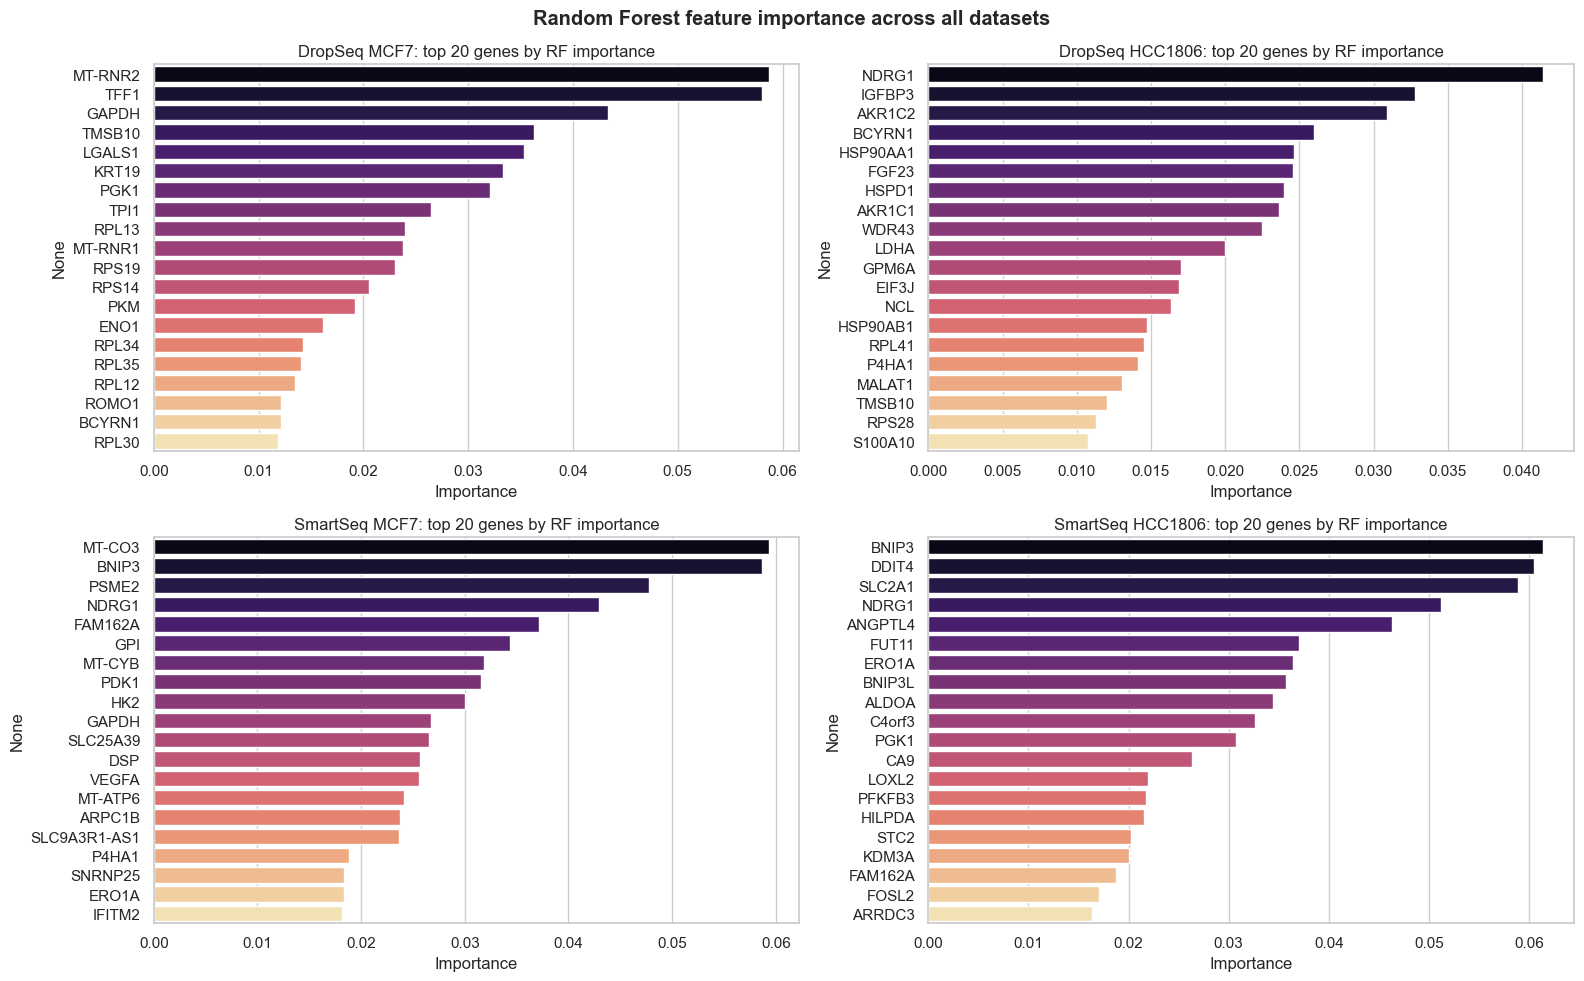

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, key in zip(axes.flat, KEYS):
    rf = trained_models[key]['RandomForest']
    imp = pd.Series(rf.feature_importances_, index=top_genes[key]).sort_values(ascending=False)
    sns.barplot(x=imp.values[:20], y=imp.index[:20], palette='magma', ax=ax)
    ax.set_title(f'{key[0]} {key[1]}: top 20 genes by RF importance')
    ax.set_xlabel('Importance')
plt.suptitle('Random Forest feature importance across all datasets', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.7 Cross-line comparison

#### 5.7.1 Top-gene overlap

How many of the top-500 MI genes are shared between the two cell lines? A large overlap suggests a shared hypoxia transcriptional programme; a small overlap suggests the two lines activate different gene sets.

=== Within-technology gene overlap (MCF7 vs HCC1806) ===
DropSeq: shared=105, MCF7 only=395, HCC1806 only=395
SmartSeq: shared=93, MCF7 only=407, HCC1806 only=407

=== Cross-technology gene overlap (DropSeq vs SmartSeq) ===
MCF7: shared=39, DropSeq only=461, SmartSeq only=461
HCC1806: shared=48, DropSeq only=452, SmartSeq only=452


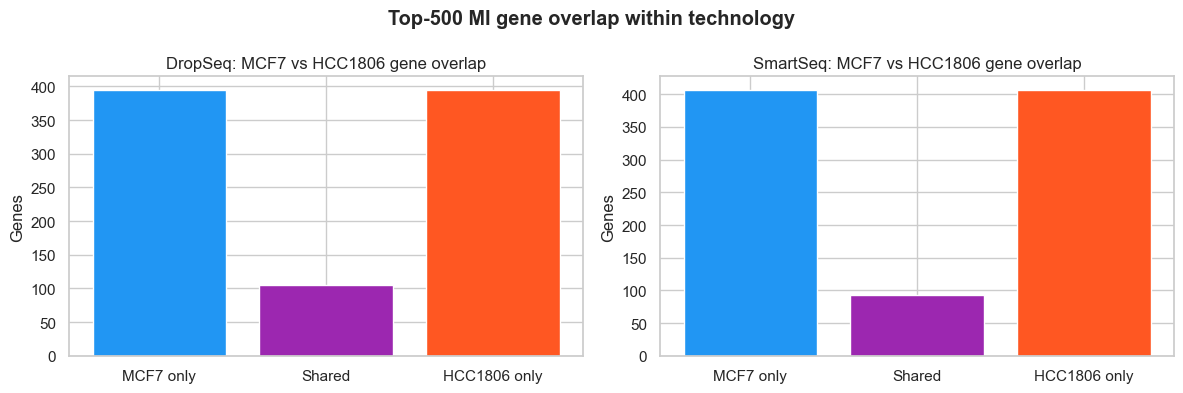

In [59]:
print("=== Within-technology gene overlap (MCF7 vs HCC1806) ===")
for tech in TECHS:
    s1 = set(top_genes[(tech, 'MCF7')])
    s2 = set(top_genes[(tech, 'HCC1806')])
    print(f"{tech}: shared={len(s1 & s2)}, MCF7 only={len(s1 - s2)}, HCC1806 only={len(s2 - s1)}")

print()
print("=== Cross-technology gene overlap (DropSeq vs SmartSeq) ===")
for line in LINES:
    s1 = set(top_genes[('DropSeq', line)])
    s2 = set(top_genes[('SmartSeq', line)])
    print(f"{line}: shared={len(s1 & s2)}, DropSeq only={len(s1 - s2)}, SmartSeq only={len(s2 - s1)}")

# Bar chart — within technology
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tech in zip(axes, TECHS):
    s1 = set(top_genes[(tech, 'MCF7')])
    s2 = set(top_genes[(tech, 'HCC1806')])
    ax.bar(['MCF7 only', 'Shared', 'HCC1806 only'],
           [len(s1 - s2), len(s1 & s2), len(s2 - s1)],
           color=['#2196F3', '#9C27B0', '#FF5722'])
    ax.set_title(f'{tech}: MCF7 vs HCC1806 gene overlap')
    ax.set_ylabel('Genes')
plt.suptitle(f'Top-{N_TOP_GENES} MI gene overlap within technology', fontweight='bold')
plt.tight_layout()
plt.show()


#### 5.7.2 CV accuracy: MCF7 vs HCC1806 bar chart

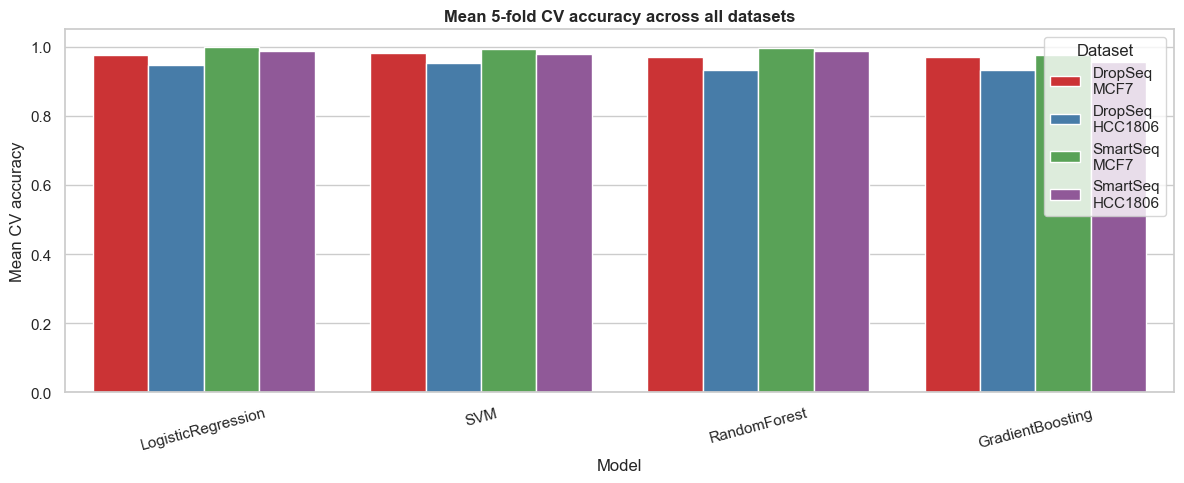

In [60]:
rows = []
for key in KEYS:
    for name, scores in cv_results[key].items():
        rows.append({'Dataset': f'{key[0]}\n{key[1]}', 'Model': name,
                     'Mean CV accuracy': scores.mean()})
df_plot = pd.DataFrame(rows)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_plot, x='Model', y='Mean CV accuracy', hue='Dataset', palette='Set1')
plt.title('Mean 5-fold CV accuracy across all datasets', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 5.8 Summary of results
### Feature selection
Both lines start from 3,000 HVGs. After variance filtering and top-500 MI selection, the surviving gene sets overlap partially but not completely, suggesting a shared core hypoxia programme alongside cell-line-specific responses.

### Cross-validation
| Model | MCF7 mean acc | HCC1806 mean acc |
|---|---|---|
| Logistic Regression | 0.9767 | 0.9472 |
| SVM (RBF) | **0.9807** | **0.9541** |
| Random Forest | 0.9699 | 0.9318 |
| Gradient Boosting | 0.9703 | 0.9313 |

SVM-RBF is the best model on both lines. MCF7 accuracies are consistently ~3 pp higher than HCC1806, consistent with its stronger and more developed hypoxia signal (72 h vs 24 h exposure, cleaner PCA separation in the unsupervised notebook).

## 6. Generalization

This section tests whether the classifiers trained in section 5 generalize beyond their training conditions. Two types of generalization are evaluated:

1. **Cross-cell-line**: a model trained on MCF7 cells is applied to HCC1806 cells (and vice versa). Same technology (DropSeq), different biology.
2. **Cross-technology**: a model trained on DropSeq data is applied to SmartSeq data from the same cell line, and vice versa. Same biology, different sequencing platform.

All models, gene lists, and training data are already in memory from section 5 — no reloading needed.

### 6.1. Gene-set overlap summary

Before running models across conditions, it is useful to know how much the feature sets overlap. Low overlap means a model will receive mostly zero-filled inputs when applied to a different condition — the closer to chance the performance, the more this is a feature-coverage problem rather than a biology problem.

In [ ]:
print('=== Within-technology gene overlap (MCF7 vs HCC1806) ===')
for tech in ['DropSeq', 'SmartSeq']:
    s1 = set(top_genes[(tech, 'MCF7')])
    s2 = set(top_genes[(tech, 'HCC1806')])
    print(f'{tech}    MCF7 vs HCC1806 : {len(s1 & s2)} shared  '
          f'({len(s1 - s2)} MCF7-only, {len(s2 - s1)} HCC1806-only)')

print()
print('=== Cross-technology gene overlap (DropSeq vs SmartSeq) ===')
for line in ['MCF7', 'HCC1806']:
    s1 = set(top_genes[('DropSeq', line)])
    s2 = set(top_genes[('SmartSeq', line)])
    print(f'{line:8s}  DropSeq vs SmartSeq : {len(s1 & s2)} shared  '
          f'({len(s1 - s2)} DropSeq-only, {len(s2 - s1)} SmartSeq-only)')


### 6.2. Helper functions

In [ ]:
def select_genes(df, gene_list):
    """
    Subset df columns to gene_list in training order.
    Genes absent from df are zero-filled (not detected / different platform).
    Built in a single concat to avoid DataFrame fragmentation.
    """
    present = [g for g in gene_list if g in df.columns]
    missing = [g for g in gene_list if g not in df.columns]
    parts = [df[present]]
    if missing:
        parts.append(pd.DataFrame(0.0, index=df.index, columns=missing))
    return pd.concat(parts, axis=1)[gene_list].values


def run_models(cell_line_models, X, y, scenario, train_tech, train_line, test_tech, test_line):
    rows = []
    for mname, model in cell_line_models.items():
        yp = model.predict(X)
        rows.append({
            'scenario':   scenario,
            'train_tech': train_tech,
            'train_line': train_line,
            'test_tech':  test_tech,
            'test_line':  test_line,
            'model':      mname,
            'acc':        round(accuracy_score(y, yp), 4),
            'bacc':       round(balanced_accuracy_score(y, yp), 4),
        })
    return rows


### 6.3. In-Distribution Baseline

Each model is re-applied to the data it was **trained on** (training set, not held-out). Scores here are inflated for models that overfit (especially Random Forest, which memorises training data). These are included only as a ceiling reference, not as valid generalisation estimates.

In [ ]:
results = []

for key in KEYS:
    X = select_genes(train_raw[key], top_genes[key])
    y = y_train[key]
    results += run_models(
        trained_models[key], X, y,
        scenario='in-dist',
        train_tech=key[0], train_line=key[1],
        test_tech=key[0],  test_line=key[1],
    )

pd.DataFrame(results).sort_values(['train_tech', 'train_line', 'model'])


### 6.4. Cross-Cell-Line Generalization

DropSeq-trained models are applied to the other cell line's DropSeq data. The two cell lines share only **105** of their top-500 MI genes (DropSeq) — genes absent from the target data are zero-filled.

In [ ]:
for train_line, test_line in [('MCF7', 'HCC1806'), ('HCC1806', 'MCF7')]:
    key_train = ('DropSeq', train_line)
    key_test  = ('DropSeq', test_line)
    df = train_raw[key_test]
    y  = y_train[key_test]
    n_present = sum(1 for g in top_genes[key_train] if g in df.columns)
    print(f'DropSeq {train_line} → {test_line}: {n_present}/500 training genes present in target')
    X = select_genes(df, top_genes[key_train])
    results += run_models(
        trained_models[key_train], X, y,
        scenario='cross-cell',
        train_tech='DropSeq', train_line=train_line,
        test_tech='DropSeq',  test_line=test_line,
    )

pd.DataFrame([r for r in results if r['scenario'] == 'cross-cell']).sort_values(['train_line', 'model'])


### 6.5. Cross-Technology Generalization

Models trained on one sequencing technology are tested on the same cell line measured with the other technology. We test both directions:
- **DropSeq → SmartSeq**: DropSeq-trained model applied to SmartSeq data
- **SmartSeq → DropSeq**: SmartSeq-trained model applied to DropSeq data

The cross-technology gene overlap is very low (39 genes for MCF7, 48 for HCC1806) because mutual information feature selection was run independently on each dataset, and the two technologies measure slightly different gene sets with different noise profiles.

In [ ]:
for line in ['MCF7', 'HCC1806']:
    for train_tech, test_tech in [('DropSeq', 'SmartSeq'), ('SmartSeq', 'DropSeq')]:
        key_train = (train_tech, line)
        key_test  = (test_tech,  line)
        df = train_raw[key_test]
        y  = y_train[key_test]
        n_present = sum(1 for g in top_genes[key_train] if g in df.columns)
        print(f'{line} {train_tech} → {test_tech}: {n_present}/500 training genes present')
        X = select_genes(df, top_genes[key_train])
        results += run_models(
            trained_models[key_train], X, y,
            scenario='cross-tech',
            train_tech=train_tech, train_line=line,
            test_tech=test_tech,   test_line=line,
        )

pd.DataFrame([r for r in results if r['scenario'] == 'cross-tech']).sort_values(['train_line', 'train_tech', 'model'])


### 6.6. Summary and Visualization

In [ ]:
results_df = pd.DataFrame(results)

# For in-dist, average over the 4 datasets; for cross-cell/cross-tech average over directions
pivot = results_df.pivot_table(
    values='bacc',
    index='model',
    columns='scenario',
    aggfunc='mean',
)[['in-dist', 'cross-cell', 'cross-tech']]

fig, ax = plt.subplots(figsize=(9, 4))
palette = ['#2a9d8f', '#e76f51', '#e9c46a']
pivot.plot(kind='bar', ax=ax, color=palette, edgecolor='white', width=0.7)
ax.axhline(0.5, linestyle='--', linewidth=0.8, color='grey', label='chance (0.5)')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Generalization: mean balanced accuracy by scenario and model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Scenario')
ax.set_ylim(0, 1.08)
plt.tight_layout()
plt.savefig('outputs/figures/generalization_summary.png', dpi=150)
plt.show()

print(pivot.round(3).to_string())


In [ ]:
# Performance drop relative to in-distribution, broken down by direction
in_dist_mean = results_df[results_df['scenario'] == 'in-dist'].groupby('model')['bacc'].mean()
cross = results_df[results_df['scenario'] != 'in-dist'].copy()
cross['in_dist_bacc'] = cross['model'].map(in_dist_mean)
cross['drop'] = (cross['in_dist_bacc'] - cross['bacc']).round(3)

print('Performance drop (in-dist bacc − cross-condition bacc):')
print(cross[['scenario', 'train_tech', 'train_line', 'test_tech', 'test_line', 'model', 'bacc', 'drop']]
      .sort_values(['scenario', 'train_line', 'model']).to_string(index=False))


### 6.7. Interpretation

#### In-distribution baseline

All models score very high on their own training data. SmartSeq models are uniformly at or near 1.00, reflecting the near-perfect hypoxia/normoxia separation that was already visible in the unsupervised analysis (section 4). DropSeq models range from 0.94–1.00, with Random Forest hitting 1.00 on both lines — a sign of memorisation rather than learning. SVM is the most accurate model that does not perfectly overfit, with balanced accuracy 0.989 (MCF7) and 0.981 (HCC1806) on the training set.

#### Cross-cell-line generalization

Performance drops substantially in both directions, but the drop is asymmetric:

- **MCF7 → HCC1806**: balanced accuracy falls to 0.54–0.57 across all models — barely above chance (0.50). The 500 MCF7-selected genes carry almost no information about the hypoxia state in HCC1806. This most likely reflects the difference in hypoxia exposure time (MCF7: 72 h, HCC1806: 24 h): MCF7 has had time to mount a full transcriptional response, selecting genes that are strongly regulated in MCF7 but may not yet be activated in HCC1806 after only 24 h.

- **HCC1806 → MCF7**: noticeably better (balanced accuracy 0.64–0.80). SVM reaches 0.80, Logistic Regression 0.69. The HCC1806 gene signature partially overlaps the MCF7 hypoxia response — the genes activated early under hypoxia (HCC1806, 24 h) are a subset of those that remain active at 72 h (MCF7).

The low gene overlap between the two cell lines (105/500 for DropSeq, 93/500 for SmartSeq) is a contributing factor, but not the whole story: even among the 179–212 DropSeq genes that are present in the target cell line's data, the MCF7 signal is too cell-line-specific to generalise downward (shorter exposure).

#### Cross-technology generalization

This is the hardest test, and the results are mostly poor — but with a notable exception:

- **SVM, Random Forest, and Gradient Boosting collapse to exactly 0.50** in all four cross-technology conditions. These are tree-based and kernel methods that build complex, high-dimensional decision boundaries. When 88–92 % of input features are zero-filled (because only 39–48 of 500 training genes are present in the other technology's data), the decision boundary is essentially undefined and the models predict a constant class, landing at chance-level balanced accuracy.

- **Logistic Regression is the only model that generalises across technologies**, and only in one direction: **DropSeq → SmartSeq MCF7** achieves 0.956 balanced accuracy, and **SmartSeq → DropSeq MCF7** achieves 0.746. HCC1806 cross-technology performance is poor for all models including LR (0.51–0.62), suggesting the MCF7 result is not a general property of LR but of the specific genes that happen to survive the cross-technology gap for MCF7.

The reason LR generalises where tree/kernel methods do not is structural: LR learns a sparse linear combination of the available (non-zero) genes, and if even a few of those genes carry the hypoxia signal consistently across technologies, LR can exploit them. SVM and ensemble methods need more of the feature space to be populated to function.

The cross-technology gene overlap is very low (39 for MCF7, 48 for HCC1806) because mutual information feature selection was run independently on each technology, capturing technology-specific noise patterns alongside the true biological signal. A model designed for cross-technology robustness would select features on the **intersection** of the two gene panels before training.

#### Overall conclusion

Generalisation degrades substantially as soon as training conditions change. The classifiers learned a mixture of true biology and condition-specific artefacts. The best single-direction result is SVM HCC1806 → MCF7 DropSeq (0.80 balanced accuracy), suggesting partial conservation of the early hypoxia response. Cross-technology generalisation is almost exclusively achieved by Logistic Regression on MCF7, likely because a small number of strongly regulated genes survive the DropSeq/SmartSeq gap for that cell line. For a deployable classifier, future work should: (1) select features on a shared gene panel across technologies; (2) use held-out cross-validation rather than in-sample evaluation; and (3) test on genuinely unseen biological replicates.


## 7. conclusion